# SoilMind: An Integrated Representation Learning Framework for Soil Microbial Abundance and Ecological Generalization

## - Soil microbial abundance prediction, subgroup modeling, explainable AI, and ecological representation learning

This notebook documents the complete SoilMind analytical workflow from raw integrated ecological data to complete ready modelling outputs. The pipeline is intentionally structured as a reproducible research notebook where each stage records what is being done, why it is methodologically necessary and how the resulting outputs should be interpreted.

The central prediction target is microbial abundance represented through `log_meanCopyNumber`. The workflow therefore focuses on ecological signal extraction rather than simple predictive fitting. Particular attention is given to data auditing, leakage control, strict validation, subgroup analysis, explainable AI, unsupervised ecological state discovery, ablation testing, and representation learning generalization.

## Imports

This cell loads the scientific Python stack used throughout the notebook. The imports cover data handling, visualization, machine learning, model evaluation, explainability, statistical testing, and file export. Keeping the imports together improves reproducibility because the required libraries are visible before any analysis is executed.

In [1]:
import os
import random
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import files  # Colab-only convenience
except ImportError:
    files = None

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from scipy import stats

from xgboost import XGBRegressor
import shap


## Reproducibility and plotting setup

This cell fixes the random seed across Python and NumPy so that train/test splits, model initialization, and repeated validation procedures are more stable between runs. The plotting defaults are also standardized so that figures generated later in the notebook have a consistent appearance suitable for reporting.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_context("notebook")
sns.set_style("whitegrid")

print("Random seed fixed at:", SEED)

Random seed fixed at: 42


## Output folders for journal artifacts

This cell creates a structured output directory for figures, tables, datasets, and trained models. Saving artifacts in separate folders makes the notebook easier to audit because exported results can be traced back to the section that produced them.

In [3]:
BASE_DIR = Path("content/SoilMind_outputs2")
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"

for folder in [BASE_DIR, FIG_DIR, TABLE_DIR, DATA_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Created output folders:")
print("BASE_DIR :", BASE_DIR)
print("FIG_DIR  :", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

Created output folders:
BASE_DIR : content/SoilMind_outputs2
FIG_DIR  : content/SoilMind_outputs2/figures
TABLE_DIR: content/SoilMind_outputs2/tables
DATA_DIR : content/SoilMind_outputs2/data
MODEL_DIR: content/SoilMind_outputs2/models


## Load the integrated SoilMind dataset

This cell loads the final integrated SoilMind dataset using a local path first and a Colab upload fallback when the file is not already available. This design keeps the notebook portable across local machines and cloud notebooks without changing the analysis code.

In [4]:
DEFAULT_DATA_PATHS = [
    "SoilMind_v3_with_coordinates_and_nasa.csv",
    r"/content/SoilMind_v3_with_coordinates_and_nasa.csv"
]

file_name = next((p for p in DEFAULT_DATA_PATHS if os.path.exists(p)), None)

if file_name is None:
    raise FileNotFoundError(
        "CSV file not found. Put the CSV in the same folder as this notebook, "
        "or update DEFAULT_DATA_PATHS with the correct full path."
    )

print("Using dataset file:", file_name)

df = pd.read_csv(file_name)
df.head()


Using dataset file: SoilMind_v3_with_coordinates_and_nasa.csv


,uid_x,namedLocation_x,domainID_x,siteID_x,plotID_x,collectDate_x,processedDate_x,sampleMaterial_x,geneticSampleID_x,laboratoryName_x,...,soilTemp,field_latitude,field_longitude,airTemp_mean,precip_total,humidity_mean,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean
0,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
1,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
2,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
3,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
4,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,5.9,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968


## Load confirmation and first-row preview

This cell performs the `Load confirmation and first-row preview` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

In [5]:
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (26888, 80)


,uid_x,namedLocation_x,domainID_x,siteID_x,plotID_x,collectDate_x,processedDate_x,sampleMaterial_x,geneticSampleID_x,laboratoryName_x,...,soilTemp,field_latitude,field_longitude,airTemp_mean,precip_total,humidity_mean,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean
0,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
1,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
2,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
3,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
4,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,5.9,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968


## Basic dataset metadata snapshot

This cell records the dataset size, duplicate count, and total missing value burden. These checks provide a first-level audit of whether the merged dataset is suitable for modelling and whether duplicated rows or missingness could affect later results.

In [6]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Duplicate rows",
        "Total missing values"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ]
})

display(dataset_summary)
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)

,Metric,Value
0,Number of rows,26888
1,Number of columns,80
2,Duplicate rows,0
3,Total missing values,191856


## Column inventory and variable audit

This cell creates a table of column names, data types, missing counts, and missing percentages. The inventory is important because SoilMind combines microbial, soil, climate, spatial, and temporal sources; the audit confirms which variables are available and how complete they are before modelling decisions are made.

In [7]:
column_inventory = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
})

display(column_inventory.head(20))
column_inventory.to_csv(TABLE_DIR / "column_inventory.csv", index=False)

,column,dtype,missing_count,missing_percent,n_unique
0,uid_x,object,0,0.000000,7668
1,namedLocation_x,object,0,0.000000,242
2,domainID_x,object,0,0.000000,8
3,siteID_x,object,0,0.000000,22
4,plotID_x,object,0,0.000000,242
5,collectDate_x,object,0,0.000000,3622
6,processedDate_x,object,0,0.000000,167
7,sampleMaterial_x,object,0,0.000000,2
8,geneticSampleID_x,object,0,0.000000,3872
9,laboratoryName_x,object,0,0.000000,2


## Full DataFrame information

This cell prints the full pandas schema for the dataset. It is used as a transparent technical checkpoint to verify column types, memory use, and non null counts before cleaning and feature engineering.

In [8]:
print("DataFrame info:")
df.info()

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26888 entries, 0 to 26887
Data columns (total 80 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   uid_x                        26888 non-null  object 
 1   namedLocation_x              26888 non-null  object 
 2   domainID_x                   26888 non-null  object 
 3   siteID_x                     26888 non-null  object 
 4   plotID_x                     26888 non-null  object 
 5   collectDate_x                26888 non-null  object 
 6   processedDate_x              26888 non-null  object 
 7   sampleMaterial_x             26888 non-null  object 
 8   geneticSampleID_x            26888 non-null  object 
 9   laboratoryName_x             26888 non-null  object 
 10  dnaSampleID                  26888 non-null  object 
 11  dnaSampleCode                6475 non-null   object 
 12  internalLabID_x              25484 non-null  object 
 13  

## Data type summary export

This cell converts the column data types into an exportable table. Saving the data type summary supports reproducibility because later readers can check exactly how variables were represented at the start of the workflow.

In [9]:
dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})

dtype_summary.to_csv(TABLE_DIR / "dtype_summary.csv", index=False)
print("Saved dtype summary.")

Saved dtype summary.


## Missing-value summary

This cell quantifies missingness column by column and exports the result. The purpose is not only to identify incomplete variables, but also to justify later cleaning, exclusion, or imputation decisions using documented evidence rather than arbitrary choices.

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

missing_df_nonzero = missing_df[missing_df["Missing Count"] > 0]

display(missing_df_nonzero)
missing_df_nonzero.to_csv(TABLE_DIR / "missing_values_summary.csv")
print("Saved missing values summary.")

,Missing Count,Missing Percent
nucleicAcidPurity,26888,100.000000
dataQF_y,24466,90.992264
deprecatedVialID,24465,90.988545
remarks_y,24465,90.988545
dataQF_x,22507,83.706486
dnaSampleCode,20413,75.918625
remarks_x,3407,12.671080
soilInWaterpH_std,2662,9.900327
soilInWaterpH_mean,2535,9.427998
internalLabID_y,2423,9.011455


Saved missing values summary.


## Missingness heatmap

This cell visualizes the missing-value pattern across the dataset. The heatmap helps detect structured gaps that may come from particular source tables, years, sites, or merged data blocks. Such patterns matter because missingness may reflect data-collection design rather than random noise.

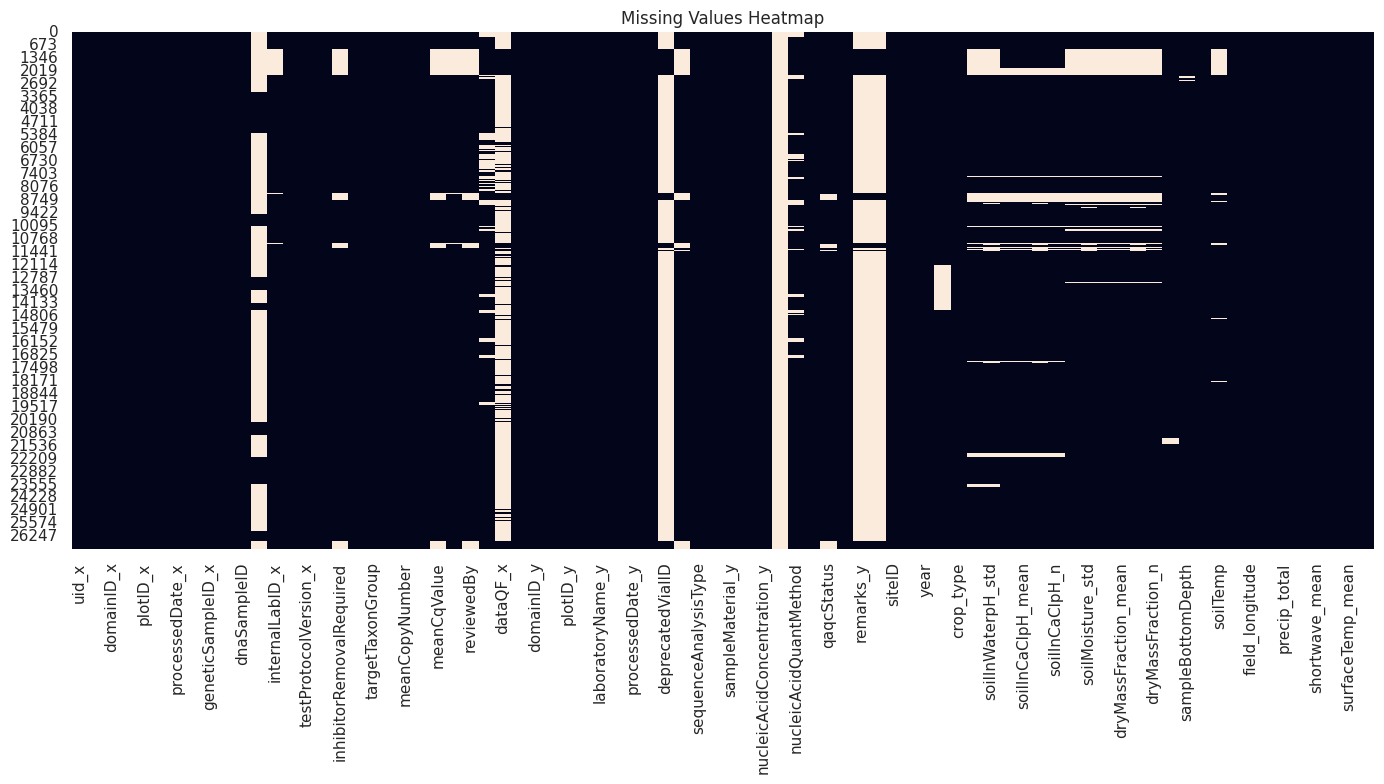

In [11]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_values_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Target variable inspection

This cell checks the microbial abundance target, `meanCopyNumber`, for missing and zero values. This is an essential step because the target distribution determines whether transformation is required and whether rows are valid for supervised learning.

In [12]:
target_col = "meanCopyNumber"

print("Missing in target:", df[target_col].isnull().sum())
print("Zero values in target:", (df[target_col] == 0).sum())

target_summary = df[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(target_summary)

target_summary.to_csv(TABLE_DIR / "raw_target_summary.csv")

Missing in target: 0
Zero values in target: 1027


,meanCopyNumber
count,2.688800e+04
mean,4.747772e+07
std,4.039727e+08
min,0.000000e+00
25%,3.520000e+01
50%,2.495800e+03
75%,4.236275e+04
90%,1.146063e+05
95%,1.119833e+06
99%,1.479221e+09


## Raw target distribution

This cell plots the untransformed microbial abundance distribution. The raw qPCR copy-number scale is typically highly skewed, so this figure provides the visual justification for applying a log transformation before modelling.

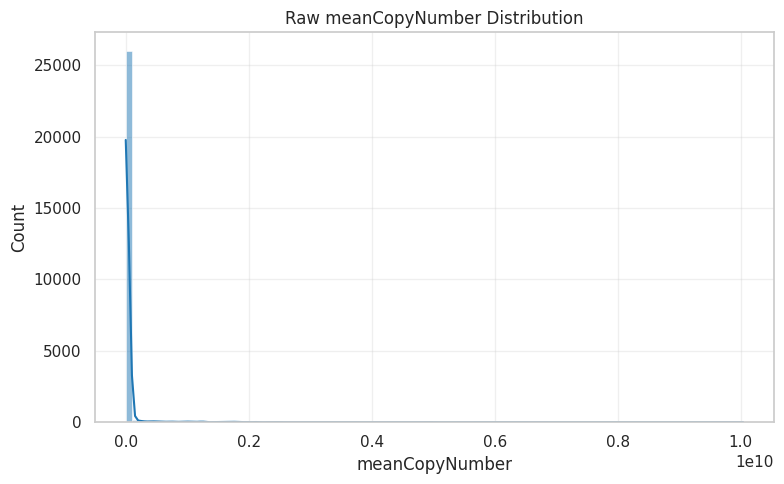

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], bins=100, kde=True)
plt.title("Raw meanCopyNumber Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "raw_meanCopyNumber_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Log-transformed target creation

This cell creates `log_meanCopyNumber` using a log one-plus transformation and plots the transformed distribution. The transformation reduces extreme skewness while preserving zero values, making the target more suitable for regression models and more interpretable in terms of relative abundance differences.

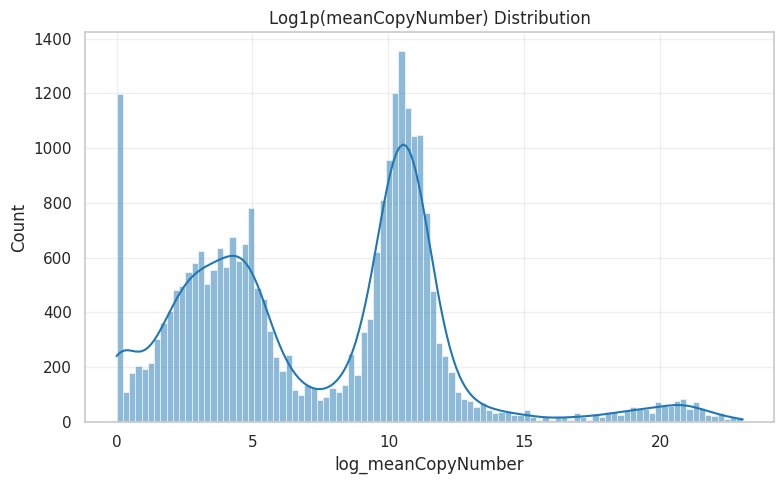

,log_meanCopyNumber
count,26888.000000
mean,7.415735
std,4.639587
min,0.000000
25%,3.589059
50%,7.822757
75%,10.654048
90%,11.649267
95%,13.928691
99%,21.114782


In [14]:
df["log_meanCopyNumber"] = np.log1p(df[target_col])

plt.figure(figsize=(8, 5))
sns.histplot(df["log_meanCopyNumber"], bins=100, kde=True)
plt.title("Log1p(meanCopyNumber) Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "log_meanCopyNumber_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

log_target_summary = df["log_meanCopyNumber"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(log_target_summary)
log_target_summary.to_csv(TABLE_DIR / "log_target_summary.csv")

## Key grouping columns overview

This cell inspects site, plot, time, taxonomic, and crop-history columns that can be used for stratification, subgroup analysis, or strict validation. These grouping variables are important because random splits can overestimate performance when samples from the same site or period appear in both training and test sets.

In [15]:
candidate_cols = [
    "siteID", "siteID_x",
    "plotID", "plotID_x",
    "year_month",
    "targetGene",
    "targetTaxonGroup",
    "crop_type"
]

grouping_summary = []

for col in candidate_cols:
    if col in df.columns:
        grouping_summary.append({
            "column": col,
            "n_unique": df[col].nunique(dropna=True),
            "sample_values": ", ".join(map(str, df[col].dropna().astype(str).unique()[:10]))
        })

grouping_summary_df = pd.DataFrame(grouping_summary)
display(grouping_summary_df)
grouping_summary_df.to_csv(TABLE_DIR / "grouping_columns_summary.csv", index=False)

,column,n_unique,sample_values
0,siteID,22,"BART, HARV, BLAN, SCBI, SERC, DSNY, JERC, OSBS..."
1,siteID_x,22,"BART, HARV, BLAN, SCBI, SERC, DSNY, JERC, OSBS..."
2,plotID_x,242,"BART_004, BART_028, BART_040, BART_071, BART_0..."
3,year_month,46,"2014-05, 2014-06, 2014-07, 2016-04, 2016-07, 2..."
4,targetGene,2,"ITS, 16S"
5,targetTaxonGroup,4,"fungi, bacteria and archaea, archaea, bacteria"
6,crop_type,8,"Mixed Forest, Deciduous Forest, Grass/Pasture,..."


## Detect duplicated merge-suffix columns

This cell identifies `_x` and `_y` column pairs created during dataset merging. Detecting these pairs is necessary because duplicated merge outputs can introduce redundant information, ambiguity, or accidental leakage if not reviewed carefully.

In [16]:
x_y_pairs = []

for col in df.columns:
    if col.endswith("_x"):
        base = col[:-2]
        y_col = base + "_y"
        if y_col in df.columns:
            x_y_pairs.append((col, y_col))

x_y_pairs_df = pd.DataFrame(x_y_pairs, columns=["Column_X", "Column_Y"])
display(x_y_pairs_df)
x_y_pairs_df.to_csv(TABLE_DIR / "x_y_pairs.csv", index=False)

print("Total _x/_y pairs found:", len(x_y_pairs))

,Column_X,Column_Y
0,uid_x,uid_y
1,namedLocation_x,namedLocation_y
2,domainID_x,domainID_y
3,siteID_x,siteID_y
4,plotID_x,plotID_y
5,collectDate_x,collectDate_y
6,processedDate_x,processedDate_y
7,sampleMaterial_x,sampleMaterial_y
8,geneticSampleID_x,geneticSampleID_y
9,laboratoryName_x,laboratoryName_y


Total _x/_y pairs found: 15


## Compare duplicated merge-suffix columns

This cell compares each `_x` and `_y` pair to determine whether the duplicated columns contain identical or conflicting values. The comparison supports transparent decisions about which version to keep or remove during cleaning.

In [17]:
comparison_results = []

for col_x, col_y in x_y_pairs:
    same = (df[col_x].fillna("MISSING") == df[col_y].fillna("MISSING")).sum()
    total = len(df)
    match_percent = same / total * 100

    comparison_results.append({
        "Column X": col_x,
        "Column Y": col_y,
        "Matching Rows": same,
        "Total Rows": total,
        "Match Percent": round(match_percent, 2)
    })

comparison_df = pd.DataFrame(comparison_results).sort_values(by="Match Percent", ascending=False)
display(comparison_df)
comparison_df.to_csv(TABLE_DIR / "x_y_pair_comparison.csv", index=False)

,Column X,Column Y,Matching Rows,Total Rows,Match Percent
1,namedLocation_x,namedLocation_y,26888,26888,100.00
2,domainID_x,domainID_y,26888,26888,100.00
3,siteID_x,siteID_y,26888,26888,100.00
5,collectDate_x,collectDate_y,26888,26888,100.00
4,plotID_x,plotID_y,26888,26888,100.00
8,geneticSampleID_x,geneticSampleID_y,26888,26888,100.00
9,laboratoryName_x,laboratoryName_y,26824,26888,99.76
12,nucleicAcidConcentration_x,nucleicAcidConcentration_y,26788,26888,99.63
7,sampleMaterial_x,sampleMaterial_y,26006,26888,96.72
10,internalLabID_x,internalLabID_y,25861,26888,96.18


## Advanced cleaning rules

This cell applies the main cleaning decisions used to create the modelling dataset. Columns that are unusable, highly incomplete, merge noisy, or likely to encode laboratory/process artifacts are removed so that the final models focus more strongly on ecological predictors.

In [18]:
df_clean = df.copy()

# Drop unusable / highly incomplete / merge-noise columns
drop_cols_strict = [
    "nucleicAcidPurity",
    "deprecatedVialID",
    "dataQF_x", "dataQF_y",
    "remarks_x", "remarks_y",
    "dnaSampleCode",
    "uid_x", "uid_y",
    "processedDate_x", "processedDate_y",
    "testProtocolVersion_x", "testProtocolVersion_y"
]

df_clean = df_clean.drop(
    columns=[c for c in drop_cols_strict if c in df_clean.columns],
    errors="ignore"
)

# Drop _y columns where _x was retained
drop_y_cols = [
    "namedLocation_y",
    "domainID_y",
    "siteID_y",
    "plotID_y",
    "collectDate_y",
    "geneticSampleID_y",
    "laboratoryName_y",
    "nucleicAcidConcentration_y",
    "sampleMaterial_y",
    "internalLabID_y"
]

df_clean = df_clean.drop(
    columns=[c for c in drop_y_cols if c in df_clean.columns],
    errors="ignore"
)

print("Shape after advanced cleaning:", df_clean.shape)

Shape after advanced cleaning: (26888, 58)


## Parse dates and create temporal features

This cell identifies the available collection date column, converts it into a datetime representation, and derives time-based variables such as year and month. These variables are needed for temporal validation, seasonal interpretation, and detecting year-level generalization behaviour.

In [19]:
date_col = None

for c in ["collectDate", "collectDate_x"]:
    if c in df_clean.columns:
        date_col = c
        break

print("Using date column:", date_col)

if date_col is not None:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors="coerce")
    df_clean["year_from_date"] = df_clean[date_col].dt.year
    df_clean["month"] = df_clean[date_col].dt.month
else:
    print("No direct collectDate column found.")

Using date column: collectDate_x


## Parse year-month values where available

This cell performs the `Parse year-month values where available` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation learning stage rather than as an isolated calculation.

In [20]:
if "year_month" in df_clean.columns:
    df_clean["year_month_parsed"] = pd.to_datetime(df_clean["year_month"], errors="coerce")
    if "month" not in df_clean.columns:
        df_clean["month"] = df_clean["year_month_parsed"].dt.month
    if "year_from_date" not in df_clean.columns:
        df_clean["year_from_date"] = df_clean["year_month_parsed"].dt.year

## Create season feature

This cell converts calendar month into an Australian-season category. The seasonal feature provides an interpretable ecological time signal that can capture broad climatic and biological differences without requiring the model to infer seasonality only from raw month values.

In [21]:
def month_to_season(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df_clean["season"] = df_clean["month"].apply(month_to_season)

display(df_clean[["month", "season"]].head())

,month,season
0,5,Autumn
1,5,Autumn
2,5,Autumn
3,5,Autumn
4,5,Autumn


## Missingness after cleaning and before imputation

This cell recalculates missingness after the initial cleaning rules have been applied. The purpose is to verify whether problematic columns have been removed and to document the remaining missing value structure before imputation is performed.

In [22]:
missing_clean = df_clean.isnull().sum().sort_values(ascending=False)
missing_clean_percent = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)

missing_clean_df = pd.DataFrame({
    "Missing Count": missing_clean,
    "Missing Percent": missing_clean_percent
})

missing_clean_nonzero = missing_clean_df[missing_clean_df["Missing Count"] > 0]
display(missing_clean_nonzero)
missing_clean_nonzero.to_csv(TABLE_DIR / "missing_after_cleaning_before_imputation.csv")

,Missing Count,Missing Percent
soilInWaterpH_std,2662,9.900327
soilInWaterpH_mean,2535,9.427998
soilMoisture_std,2402,8.933353
dryMassFraction_std,2402,8.933353
inhibitorRemovalRequired,2367,8.803184
crop_code,2363,8.788307
meanCqValue,2359,8.773431
reviewedBy,2359,8.773431
soilMoisture_n,2333,8.676733
soilMoisture_mean,2333,8.676733


## Impute remaining missing values

This cell fills missing numeric variables with medians and categorical variables with mode values. Median imputation is used for numeric ecological variables because it is less sensitive to extreme values, while mode imputation preserves the most common categorical state when limited missingness remains.

In [23]:
df_model_ready = df_clean.copy()

for col in df_model_ready.select_dtypes(include=[np.number]).columns:
    df_model_ready[col] = df_model_ready[col].fillna(df_model_ready[col].median())

for col in df_model_ready.select_dtypes(include=["object", "category"]).columns:
    if df_model_ready[col].isnull().sum() > 0:
        mode_vals = df_model_ready[col].mode()
        if len(mode_vals) > 0:
            df_model_ready[col] = df_model_ready[col].fillna(mode_vals[0])

print("Remaining missing values after imputation:", df_model_ready.isnull().sum().sum())

Remaining missing values after imputation: 1


## Save raw, cleaned, and model ready datasets

This cell exports three dataset versions: the original uploaded data, the cleaned pre-imputation data, and the final model ready data. Keeping all three versions supports traceability, allowing later reviewers to distinguish raw evidence from cleaned and imputed modelling inputs.

In [24]:
df.to_csv(DATA_DIR / "v1_raw_uploaded.csv", index=False)
df_clean.to_csv(DATA_DIR / "v2_cleaned_before_imputation.csv", index=False)
df_model_ready.to_csv(DATA_DIR / "v3_model_ready_full.csv", index=False)

print("Saved cleaned data versions.")

Saved cleaned data versions.


## Create taxonomic subgroup datasets

This cell separates the dataset into fungi and bacteria/archaea subsets where the taxonomic labels are available. Subgroup modelling is important because microbial groups can respond differently to soil, climate, and spatial drivers, so a single global model may hide biologically meaningful differences.

In [25]:
if "targetTaxonGroup" in df_model_ready.columns:
    fungi_df = df_model_ready[df_model_ready["targetTaxonGroup"].str.lower() == "fungi"].copy()

    bacteria_archaea_labels = ["bacteria and archaea", "bacteria", "archaea"]
    bacteria_archaea_df = df_model_ready[
        df_model_ready["targetTaxonGroup"].str.lower().isin(bacteria_archaea_labels)
    ].copy()

    print("Global dataset shape:", df_model_ready.shape)
    print("Fungi dataset shape:", fungi_df.shape)
    print("Bacteria/Archaea dataset shape:", bacteria_archaea_df.shape)

    fungi_df.to_csv(DATA_DIR / "v3_model_ready_fungi.csv", index=False)
    bacteria_archaea_df.to_csv(DATA_DIR / "v3_model_ready_bacteria_archaea.csv", index=False)
else:
    print("targetTaxonGroup column not found.")

Global dataset shape: (26888, 62)
Fungi dataset shape: (13074, 62)
Bacteria/Archaea dataset shape: (13814, 62)


## Define the strict ecological feature set

This cell defines the predictors allowed in the ecological modelling pipeline. The feature set prioritizes soil, climate, spatial, temporal, and land cover variables while avoiding direct laboratory process proxies that could inflate predictive performance without representing ecological mechanisms.

In [26]:
target = "log_meanCopyNumber"

ecological_features = [
    # Soil
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "horizon",

    # Climate
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean",

    # Spatial
    "field_latitude",
    "field_longitude",

    # Temporal
    "month",
    "season",

    # Crop
    "crop_type",

    # Target
    target
]

df_ecological = df_model_ready[ecological_features].copy()

print("Ecological dataset shape:", df_ecological.shape)

Ecological dataset shape: (26888, 21)


## Encode categorical ecological features

This cell applies one-hot encoding to categorical variables so that tree-based and linear models can use them numerically. `drop_first=True` reduces redundant dummy columns and helps keep the feature matrix more compact.

In [27]:
df_ecological_encoded = pd.get_dummies(df_ecological, drop_first=True)

print("Encoded shape:", df_ecological_encoded.shape)

Encoded shape: (26888, 29)


## Random train/test split for the baseline model

This cell creates the first supervised learning split used for the baseline benchmark. The random split provides a useful initial performance estimate, but it is later compared with stricter site based and time-aware validation because ecological data are spatially and temporally structured.

In [28]:
X = df_ecological_encoded.drop(columns=[target])
y = df_ecological_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (21510, 28)
Test shape: (5378, 28)


## Train the baseline XGBoost model

This cell trains an XGBoost regressor on the ecological feature matrix. XGBoost is used because it can model nonlinear relationships and interactions among soil, climate, spatial, and categorical predictors while remaining compatible with feature-importance and SHAP based interpretation.

In [29]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, y_pred)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Ecological Model")
print("R2:", xgb_r2)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

Baseline Ecological Model
R2: 0.1790100857513428
MAE: 3.7404653394294485
RMSE: 4.184544527366436


## Save baseline model results

This cell stores the baseline XGBoost performance using R², MAE, and RMSE. These metrics summarize explained variance and prediction error on the log transformed abundance scale, providing a reference point for later validation and representation learning experiments.

In [30]:
baseline_results = pd.DataFrame({
    "Model": ["Ecological_XGBoost_Baseline"],
    "R2": [xgb_r2],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse]
})

display(baseline_results)

baseline_results.to_csv(TABLE_DIR / "baseline_model_results.csv", index=False)

,Model,R2,MAE,RMSE
0,Ecological_XGBoost_Baseline,0.17901,3.740465,4.184545


## Exportable feature importance table

This cell converts the XGBoost feature importance values into a ranked table. The table is useful for identifying which ecological predictors contribute most to the baseline model, although impurity based importance should later be interpreted alongside SHAP results.

In [31]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df.head(20))

feature_importance_df.to_csv(TABLE_DIR / "baseline_feature_importance.csv", index=False)

,Feature,Importance
21,crop_type_Evergreen Forest,0.294870
14,field_latitude,0.100859
15,field_longitude,0.065342
13,topWetness_mean,0.053268
19,season_Summer,0.050181
12,surfaceTemp_mean,0.042021
24,crop_type_Shrubland,0.039309
11,par_mean,0.037488
16,month,0.036693
7,airTemp_mean,0.035316


## Plot top feature importances

This cell visualizes the highest ranked model features. The plot is intended as an exploratory interpretation tool where large bars indicate variables frequently used by the model, but the direction and context of their effects require SHAP dependence analysis or additional ecological interpretation.

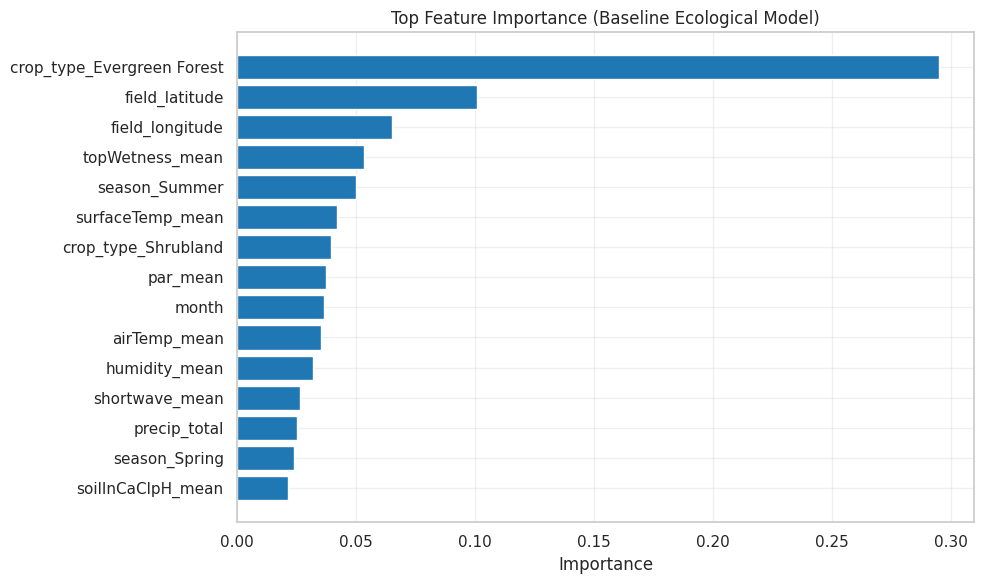

In [32]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importance (Baseline Ecological Model)")
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Rebuild encoded ecological data with grouping metadata preserved

This cell reconstructs the encoded ecological feature matrix while keeping grouping columns separately. This is necessary because group labels such as site and year should guide validation splits, but they should not necessarily be treated as ordinary predictive features in every experiment.

In [33]:
group_col_candidates = ["siteID", "siteID_x", "plotID", "plotID_x", "year", "year_from_date", "year_month"]

group_info = pd.DataFrame(index=df_model_ready.index)

for col in group_col_candidates:
    if col in df_model_ready.columns:
        group_info[col] = df_model_ready[col]

print("Available grouping columns:")
print(group_info.columns.tolist())
display(group_info.head())

Available grouping columns:
['siteID', 'siteID_x', 'plotID_x', 'year', 'year_from_date', 'year_month']


,siteID,siteID_x,plotID_x,year,year_from_date,year_month
0,BART,BART,BART_004,2014.0,2014,2014-05
1,BART,BART,BART_004,2014.0,2014,2014-05
2,BART,BART,BART_004,2014.0,2014,2014-05
3,BART,BART,BART_004,2014.0,2014,2014-05
4,BART,BART,BART_004,2014.0,2014,2014-05


## Choose grouping columns for strict validation

This cell selects the available site, plot, and year identifiers from the preserved metadata. These grouping variables enable GroupKFold and time aware testing, which are more realistic checks of whether the model generalizes beyond nearby or repeated samples.

In [34]:
site_group_col = None
for c in ["siteID", "siteID_x"]:
    if c in group_info.columns:
        site_group_col = c
        break

plot_group_col = None
for c in ["plotID", "plotID_x"]:
    if c in group_info.columns:
        plot_group_col = c
        break

year_col = None
for c in ["year", "year_from_date"]:
    if c in group_info.columns:
        year_col = c
        break

print("site_group_col:", site_group_col)
print("plot_group_col:", plot_group_col)
print("year_col:", year_col)

site_group_col: siteID
plot_group_col: plotID_x
year_col: year


## Standard 5-fold cross-validation

This cell evaluates XGBoost using shuffled 5-fold cross validation. K-fold validation reduces dependence on a single random split and provides a mean and variability estimate, but it can still be optimistic when samples from the same site or period are distributed across folds.

In [35]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

kf_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_kf, X_test_kf = X.iloc[train_idx], X.iloc[test_idx]
    y_train_kf, y_test_kf = y.iloc[train_idx], y.iloc[test_idx]

    model_kf = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    model_kf.fit(X_train_kf, y_train_kf)
    y_pred_kf = model_kf.predict(X_test_kf)

    fold_result = {
        "Fold": fold,
        "R2": r2_score(y_test_kf, y_pred_kf),
        "MAE": mean_absolute_error(y_test_kf, y_pred_kf),
        "RMSE": np.sqrt(mean_squared_error(y_test_kf, y_pred_kf))
    }
    kf_results.append(fold_result)

kf_results_df = pd.DataFrame(kf_results)
display(kf_results_df)

kf_results_df.to_csv(TABLE_DIR / "kfold_cv_results.csv", index=False)

,Fold,R2,MAE,RMSE
0,1,0.176817,3.742800,4.190129
1,2,0.216619,3.679776,4.099142
2,3,0.191719,3.736945,4.210262
3,4,0.214898,3.676460,4.093774
4,5,0.200503,3.710534,4.151363


## K-fold performance summary

This cell summarizes the cross validation results using mean and standard deviation across folds. The summary helps assess both average model performance and stability across repeated train/test partitions.

In [36]:
kf_summary = pd.DataFrame({
    "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
    "Value": [
        kf_results_df["R2"].mean(),
        kf_results_df["R2"].std(),
        kf_results_df["MAE"].mean(),
        kf_results_df["MAE"].std(),
        kf_results_df["RMSE"].mean(),
        kf_results_df["RMSE"].std()
    ]
})

display(kf_summary)
kf_summary.to_csv(TABLE_DIR / "kfold_cv_summary.csv", index=False)

,Metric,Value
0,R2_mean,0.200111
1,R2_std,0.016616
2,MAE_mean,3.709303
3,MAE_std,0.030976
4,RMSE_mean,4.148934
5,RMSE_std,0.052407


## Site based GroupKFold validation

This cell evaluates the model by holding out entire site groups during validation. This is a stronger generalization test because the model must predict microbial abundance at sites that were not represented in the training fold.

In [37]:
if site_group_col is None:
    print("No site grouping column available.")
else:
    site_groups = group_info[site_group_col]

    gkf = GroupKFold(n_splits=5)
    gkf_results = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=site_groups), start=1):
        X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
        y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

        model_g = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1
        )

        model_g.fit(X_train_g, y_train_g)
        y_pred_g = model_g.predict(X_test_g)

        gkf_results.append({
            "Fold": fold,
            "R2": r2_score(y_test_g, y_pred_g),
            "MAE": mean_absolute_error(y_test_g, y_pred_g),
            "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred_g))
        })

    gkf_results_df = pd.DataFrame(gkf_results)
    display(gkf_results_df)
    gkf_results_df.to_csv(TABLE_DIR / "groupkfold_site_results.csv", index=False)

,Fold,R2,MAE,RMSE
0,1,-0.343394,4.841991,6.361409
1,2,-0.044758,3.951993,4.469442
2,3,-0.223882,3.802421,4.351622
3,4,-0.027105,4.533523,5.460192
4,5,-0.063258,3.258492,3.655829


## Site based GroupKFold summary

This cell summarizes the GroupKFold results across site-held-out folds. A drop from random or standard K-fold performance would indicate that the model relies partly on site-specific structure and may face difficulty generalizing spatially.

In [38]:
if site_group_col is not None:
    gkf_summary = pd.DataFrame({
        "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
        "Value": [
            gkf_results_df["R2"].mean(),
            gkf_results_df["R2"].std(),
            gkf_results_df["MAE"].mean(),
            gkf_results_df["MAE"].std(),
            gkf_results_df["RMSE"].mean(),
            gkf_results_df["RMSE"].std()
        ]
    })

    display(gkf_summary)
    gkf_summary.to_csv(TABLE_DIR / "groupkfold_site_summary.csv", index=False)

,Metric,Value
0,R2_mean,-0.140480
1,R2_std,0.137940
2,MAE_mean,4.077684
3,MAE_std,0.623417
4,RMSE_mean,4.859699
5,RMSE_std,1.057765


## Time aware holdout validation

This cell evaluates temporal generalization by training on earlier years and testing on a later held-out year. This design is important because ecological models intended for future prediction should be tested against time-separated data rather than only randomly mixed observations.

In [39]:
if year_col is None:
    print("No year column available for time-aware split.")
else:
    years_sorted = sorted(group_info[year_col].dropna().unique())
    print("Available years:", years_sorted)

    # Use the last year as holdout if possible
    test_year = years_sorted[-1]
    print("Using test year:", test_year)

    train_mask = group_info[year_col] < test_year
    test_mask = group_info[year_col] == test_year

    X_train_time = X.loc[train_mask]
    X_test_time = X.loc[test_mask]
    y_train_time = y.loc[train_mask]
    y_test_time = y.loc[test_mask]

    print("Time-aware train shape:", X_train_time.shape)
    print("Time-aware test shape:", X_test_time.shape)

    xgb_time = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    xgb_time.fit(X_train_time, y_train_time)
    y_pred_time = xgb_time.predict(X_test_time)

    time_results = pd.DataFrame({
        "Model": ["Ecological_XGBoost_TimeAware"],
        "Test_Year": [test_year],
        "R2": [r2_score(y_test_time, y_pred_time)],
        "MAE": [mean_absolute_error(y_test_time, y_pred_time)],
        "RMSE": [np.sqrt(mean_squared_error(y_test_time, y_pred_time))]
    })

    display(time_results)
    time_results.to_csv(TABLE_DIR / "time_aware_results.csv", index=False)

Available years: [np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0)]
Using test year: 2018.0
Time-aware train shape: (20914, 28)
Time-aware test shape: (5974, 28)


,Model,Test_Year,R2,MAE,RMSE
0,Ecological_XGBoost_TimeAware,2018.0,-0.114325,2.687802,3.022069


## Validation comparison table

This cell combines the random split, K-fold, GroupKFold, and time-aware results into a single comparison table. The table is central for interpreting whether the model is robust under increasingly realistic validation designs.

In [40]:
validation_comparison = []

validation_comparison.append({
    "Validation": "Single Random Split",
    "R2": xgb_r2,
    "MAE": xgb_mae,
    "RMSE": xgb_rmse
})

validation_comparison.append({
    "Validation": "5-Fold CV Mean",
    "R2": kf_results_df["R2"].mean(),
    "MAE": kf_results_df["MAE"].mean(),
    "RMSE": kf_results_df["RMSE"].mean()
})

if site_group_col is not None:
    validation_comparison.append({
        "Validation": "GroupKFold by Site Mean",
        "R2": gkf_results_df["R2"].mean(),
        "MAE": gkf_results_df["MAE"].mean(),
        "RMSE": gkf_results_df["RMSE"].mean()
    })

if year_col is not None:
    validation_comparison.append({
        "Validation": "Time-Aware Holdout",
        "R2": time_results.loc[0, "R2"],
        "MAE": time_results.loc[0, "MAE"],
        "RMSE": time_results.loc[0, "RMSE"]
    })

validation_comparison_df = pd.DataFrame(validation_comparison)
display(validation_comparison_df)

validation_comparison_df.to_csv(TABLE_DIR / "validation_comparison.csv", index=False)

,Validation,R2,MAE,RMSE
0,Single Random Split,0.179010,3.740465,4.184545
1,5-Fold CV Mean,0.200111,3.709303,4.148934
2,GroupKFold by Site Mean,-0.140480,4.077684,4.859699
3,Time-Aware Holdout,-0.114325,2.687802,3.022069


## Baseline model family comparison

This section evaluates multiple regression model families under the same ecological feature setting. Comparing Ridge, Random Forest, and XGBoost helps separate the effect of model complexity from the value of the feature set itself.

## Ridge regression on the random split

This cell trains Ridge regression as a linear baseline. Ridge is useful because it provides a simple regularized reference model; if nonlinear models strongly outperform it, that suggests nonlinear ecological relationships or feature interactions are important.

In [41]:
ridge_model = Ridge(alpha=1.0, random_state=SEED)

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge - Random Split")
print("R2:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

Ridge - Random Split
R2: 0.07418965662007504
MAE: 3.8366743706025233
RMSE: 4.443654624864365


## Random Forest on the random split

This cell trains a Random Forest model on the same split. Random Forest provides a strong nonlinear tree-ensemble baseline and helps determine whether XGBoost performance is due to boosting specifically or to tree based modelling more generally.

In [42]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest - Random Split")
print("R2:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest - Random Split
R2: -0.012634532289650613
MAE: 4.141281456081108
RMSE: 4.647352868473903


## Methodological note

This short checkpoint adds context for the following code block. It clarifies why the step is included and how its output should be interpreted within the wider SoilMind modelling workflow.

## Baseline comparison on the random split

This cell places Ridge, Random Forest, and XGBoost results side by side. The comparison helps identify whether predictive gains come from nonlinear modelling capacity, ensemble learning, or regularized linear structure.

In [43]:
baseline_compare_df = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "R2": [ridge_r2, rf_r2, xgb_r2],
    "MAE": [ridge_mae, rf_mae, xgb_mae],
    "RMSE": [ridge_rmse, rf_rmse, xgb_rmse]
})

display(baseline_compare_df)

baseline_compare_df.to_csv(TABLE_DIR / "baseline_random_split_comparison.csv", index=False)

,Model,R2,MAE,RMSE
0,Ridge,0.074190,3.836674,4.443655
1,Random Forest,-0.012635,4.141281,4.647353
2,XGBoost,0.179010,3.740465,4.184545


## Ridge regression under K-fold validation

This cell evaluates the Ridge baseline under 5-fold cross validation. This provides a stability check for the linear baseline and makes the comparison with tree based models fairer than relying on a single random split.

## Methodological note

This short checkpoint adds context for the following code block. It clarifies why the step is included and how its output should be interpreted within the wider SoilMind modelling workflow.

In [44]:
ridge_kf_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_kf, X_test_kf = X.iloc[train_idx], X.iloc[test_idx]
    y_train_kf, y_test_kf = y.iloc[train_idx], y.iloc[test_idx]

    model = Ridge(alpha=1.0)
    model.fit(X_train_kf, y_train_kf)
    y_pred = model.predict(X_test_kf)

    ridge_kf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_kf, y_pred),
        "MAE": mean_absolute_error(y_test_kf, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_kf, y_pred))
    })

ridge_kf_df = pd.DataFrame(ridge_kf_results)
display(ridge_kf_df)

,Fold,R2,MAE,RMSE
0,1,0.074190,3.836674,4.443655
1,2,0.080656,3.843096,4.440637
2,3,0.063275,3.899888,4.532459
3,4,0.069608,3.852267,4.456499
4,5,0.070133,3.870401,4.477059


## Random Forest under K-fold validation

This cell evaluates Random Forest using the same K-fold partitions. The result shows how stable the nonlinear bagging model is when the dataset is repeatedly resampled.

In [45]:
rf_kf_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_kf, X_test_kf = X.iloc[train_idx], X.iloc[test_idx]
    y_train_kf, y_test_kf = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    model.fit(X_train_kf, y_train_kf)
    y_pred = model.predict(X_test_kf)

    rf_kf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_kf, y_pred),
        "MAE": mean_absolute_error(y_test_kf, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_kf, y_pred))
    })

rf_kf_df = pd.DataFrame(rf_kf_results)
display(rf_kf_df)

,Fold,R2,MAE,RMSE
0,1,-0.012520,4.139803,4.647091
1,2,0.020284,4.086052,4.584125
2,3,0.002360,4.137177,4.677510
3,4,0.028425,4.067702,4.554063
4,5,0.022628,4.085140,4.589996


## K-fold performance summary

This cell summarizes the cross-validation results using mean and standard deviation across folds. The summary helps assess both average model performance and stability across repeated train/test partitions.

In [46]:
kf_compare_df = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "R2_mean": [
        ridge_kf_df["R2"].mean(),
        rf_kf_df["R2"].mean(),
        kf_results_df["R2"].mean()
    ],
    "MAE_mean": [
        ridge_kf_df["MAE"].mean(),
        rf_kf_df["MAE"].mean(),
        kf_results_df["MAE"].mean()
    ],
    "RMSE_mean": [
        ridge_kf_df["RMSE"].mean(),
        rf_kf_df["RMSE"].mean(),
        kf_results_df["RMSE"].mean()
    ]
})

display(kf_compare_df)

kf_compare_df.to_csv(TABLE_DIR / "kfold_model_comparison.csv", index=False)

,Model,R2_mean,MAE_mean,RMSE_mean
0,Ridge,0.071572,3.860465,4.470062
1,Random Forest,0.012235,4.103175,4.610557
2,XGBoost,0.200111,3.709303,4.148934


## Ridge regression under site based GroupKFold

This cell tests the linear baseline under site-held-out validation. It provides a conservative benchmark for spatial generalization and helps determine whether nonlinear models are genuinely improving generalization or only fitting site specific patterns.

In [47]:
ridge_gkf_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=site_groups), start=1):
    X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
    y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

    model = Ridge(alpha=1.0)
    model.fit(X_train_g, y_train_g)
    y_pred = model.predict(X_test_g)

    ridge_gkf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_g, y_pred),
        "MAE": mean_absolute_error(y_test_g, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred))
    })

ridge_gkf_df = pd.DataFrame(ridge_gkf_results)
display(ridge_gkf_df)

,Fold,R2,MAE,RMSE
0,1,-0.573071,5.374402,6.883760
1,2,-0.051881,3.938061,4.484651
2,3,-0.639850,4.148237,5.037133
3,4,-0.082237,4.605418,5.604819
4,5,-0.061339,3.289285,3.652528


## Random Forest under site based GroupKFold

This cell evaluates Random Forest when entire sites are held out. Comparing this result with random-split performance reveals whether the tree ensemble generalizes spatially or depends strongly on site specific signatures.

In [48]:
rf_gkf_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=site_groups), start=1):
    X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
    y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    model.fit(X_train_g, y_train_g)
    y_pred = model.predict(X_test_g)

    rf_gkf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_g, y_pred),
        "MAE": mean_absolute_error(y_test_g, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred))
    })

rf_gkf_df = pd.DataFrame(rf_gkf_results)
display(rf_gkf_df)

,Fold,R2,MAE,RMSE
0,1,-1.357674,6.597996,8.427398
1,2,-0.048833,3.975263,4.478148
2,3,-0.164367,3.782554,4.244497
3,4,-0.089704,4.665891,5.624121
4,5,-0.058883,3.257896,3.648300


## Site based GroupKFold summary

This cell summarizes the GroupKFold results across site-held-out folds. A drop from random or standard K-fold performance would indicate that the model relies partly on site-specific structure and may face difficulty generalizing spatially.

In [49]:
gkf_compare_df = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "R2_mean": [
        ridge_gkf_df["R2"].mean(),
        rf_gkf_df["R2"].mean(),
        gkf_results_df["R2"].mean()
    ],
    "MAE_mean": [
        ridge_gkf_df["MAE"].mean(),
        rf_gkf_df["MAE"].mean(),
        gkf_results_df["MAE"].mean()
    ],
    "RMSE_mean": [
        ridge_gkf_df["RMSE"].mean(),
        rf_gkf_df["RMSE"].mean(),
        gkf_results_df["RMSE"].mean()
    ]
})

display(gkf_compare_df)

gkf_compare_df.to_csv(TABLE_DIR / "groupkfold_model_comparison.csv", index=False)

,Model,R2_mean,MAE_mean,RMSE_mean
0,Ridge,-0.281676,4.271081,5.132578
1,Random Forest,-0.343892,4.455920,5.284493
2,XGBoost,-0.140480,4.077684,4.859699


## Time aware validation for Ridge and Random Forest

This cell evaluates Ridge and Random Forest on the same temporal holdout used for XGBoost. Including multiple model families in the time aware split helps determine whether temporal generalization difficulty is model specific or dataset wide.

In [50]:
# Ridge
ridge_time = Ridge(alpha=1.0)
ridge_time.fit(X_train_time, y_train_time)
ridge_pred = ridge_time.predict(X_test_time)

# RF
rf_time = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_time.fit(X_train_time, y_train_time)
rf_pred = rf_time.predict(X_test_time)

time_compare_df = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_test_time, ridge_pred),
        r2_score(y_test_time, rf_pred),
        time_results.loc[0, "R2"]
    ],
    "MAE": [
        mean_absolute_error(y_test_time, ridge_pred),
        mean_absolute_error(y_test_time, rf_pred),
        time_results.loc[0, "MAE"]
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_time, ridge_pred)),
        np.sqrt(mean_squared_error(y_test_time, rf_pred)),
        time_results.loc[0, "RMSE"]
    ]
})

display(time_compare_df)

time_compare_df.to_csv(TABLE_DIR / "time_model_comparison.csv", index=False)

,Model,R2,MAE,RMSE
0,Ridge,-0.071905,2.650250,2.963989
1,Random Forest,-0.570421,3.038187,3.587620
2,XGBoost,-0.114325,2.687802,3.022069


## Compact hyperparameter tuning grid

This cell defines a controlled XGBoost hyperparameter search space. The grid is intentionally compact to improve the model without turning the notebook into an exhaustive tuning exercise that could overfit the validation procedure.

In [51]:
param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

print("Total parameter combinations:",
      len(param_grid["n_estimators"])
      * len(param_grid["learning_rate"])
      * len(param_grid["max_depth"])
      * len(param_grid["min_child_weight"])
      * len(param_grid["subsample"])
      * len(param_grid["colsample_bytree"]))

Total parameter combinations: 96


## Grid search on the training data

This cell runs cross validated hyperparameter tuning for XGBoost. Tuning is performed only within the training process so that the held-out test set remains an independent estimate of model performance.

In [52]:
xgb_base_for_tuning = XGBRegressor(
    random_state=SEED,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base_for_tuning,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best CV score:", grid_search.best_score_)
print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best CV score: 0.2578387263455809
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 1.0}


## Save hyperparameter tuning results

This cell exports the ranked grid-search results. The table documents which parameter settings were tested and provides evidence for why the selected configuration was chosen.

In [53]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)
grid_results_df = grid_results_df.sort_values(by="rank_test_score")

display(grid_results_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_min_child_weight",
    "param_subsample",
    "param_colsample_bytree"
]].head(15))

grid_results_df.to_csv(TABLE_DIR / "xgboost_gridsearch_results.csv", index=False)

,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree
3,1,0.257839,0.013550,500,0.03,4,1,1.0,0.8
24,2,0.257835,0.013812,300,0.05,4,1,0.8,0.8
28,3,0.257793,0.014149,300,0.05,4,3,0.8,0.8
25,4,0.257611,0.012672,300,0.05,4,1,1.0,0.8
6,5,0.257544,0.014238,500,0.03,4,3,0.8,0.8
4,6,0.257438,0.013830,300,0.03,4,3,0.8,0.8
52,7,0.257406,0.013894,300,0.03,4,3,0.8,1.0
29,8,0.257400,0.013406,300,0.05,4,3,1.0,0.8
76,9,0.257321,0.014050,300,0.05,4,3,0.8,1.0
7,10,0.257289,0.013781,500,0.03,4,3,1.0,0.8


## Train the tuned XGBoost model

This cell refits the best XGBoost configuration on the baseline training split and evaluates it on the held out test data. This shows whether tuning improves practical test performance compared with the original baseline.

In [54]:
best_xgb = grid_search.best_estimator_

best_xgb.fit(X_train, y_train)
y_pred_tuned = best_xgb.predict(X_test)

tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("Tuned XGBoost - Random Split")
print("R2:", tuned_r2)
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)

Tuned XGBoost - Random Split
R2: 0.2458464798979163
MAE: 3.6085312039191173
RMSE: 4.010598285426965


## Compare baseline and tuned XGBoost

This cell directly compares the original and tuned XGBoost models. The comparison is important because tuning should be justified by measurable improvement, not assumed to be beneficial.

In [55]:
xgb_tuning_compare_df = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Tuned XGBoost"],
    "R2": [xgb_r2, tuned_r2],
    "MAE": [xgb_mae, tuned_mae],
    "RMSE": [xgb_rmse, tuned_rmse]
})

display(xgb_tuning_compare_df)
xgb_tuning_compare_df.to_csv(TABLE_DIR / "xgboost_tuning_comparison.csv", index=False)

,Model,R2,MAE,RMSE
0,Baseline XGBoost,0.179010,3.740465,4.184545
1,Tuned XGBoost,0.245846,3.608531,4.010598


## Test tuned XGBoost under GroupKFold

This cell applies the tuned XGBoost configuration to site-based GroupKFold validation. This checks whether hyperparameter tuning improves strict spatial generalization or only benefits the easier random split.

In [56]:
tuned_gkf_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=site_groups), start=1):
    X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
    y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

    tuned_model_g = XGBRegressor(
        **grid_search.best_params_,
        random_state=SEED,
        n_jobs=-1
    )

    tuned_model_g.fit(X_train_g, y_train_g)
    y_pred_g = tuned_model_g.predict(X_test_g)

    tuned_gkf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_g, y_pred_g),
        "MAE": mean_absolute_error(y_test_g, y_pred_g),
        "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred_g))
    })

tuned_gkf_df = pd.DataFrame(tuned_gkf_results)
display(tuned_gkf_df)

tuned_gkf_df.to_csv(TABLE_DIR / "tuned_xgboost_groupkfold_results.csv", index=False)

,Fold,R2,MAE,RMSE
0,1,-0.347174,4.943837,6.370352
1,2,-0.055727,3.982596,4.492843
2,3,-0.117336,3.713833,4.157892
3,4,-0.031493,4.570614,5.471843
4,5,-0.065323,3.287404,3.659378


## Compare baseline and tuned XGBoost

This cell directly compares the original and tuned XGBoost models. The comparison is important because tuning should be justified by measurable improvement, not assumed to be beneficial.

In [57]:
tuned_group_compare_df = pd.DataFrame({
    "Model": ["Baseline XGBoost GroupKFold", "Tuned XGBoost GroupKFold"],
    "R2_mean": [
        gkf_results_df["R2"].mean(),
        tuned_gkf_df["R2"].mean()
    ],
    "MAE_mean": [
        gkf_results_df["MAE"].mean(),
        tuned_gkf_df["MAE"].mean()
    ],
    "RMSE_mean": [
        gkf_results_df["RMSE"].mean(),
        tuned_gkf_df["RMSE"].mean()
    ]
})

display(tuned_group_compare_df)
tuned_group_compare_df.to_csv(TABLE_DIR / "tuned_vs_baseline_groupkfold_comparison.csv", index=False)

,Model,R2_mean,MAE_mean,RMSE_mean
0,Baseline XGBoost GroupKFold,-0.140480,4.077684,4.859699
1,Tuned XGBoost GroupKFold,-0.123411,4.099657,4.830462


## Time-aware holdout validation

This cell evaluates temporal generalization by training on earlier years and testing on a later held out year. This design is important because ecological models intended for future prediction should be tested against time-separated data rather than only randomly mixed observations.

In [58]:
tuned_time_model = XGBRegressor(
    **grid_search.best_params_,
    random_state=SEED,
    n_jobs=-1
)

tuned_time_model.fit(X_train_time, y_train_time)
tuned_time_pred = tuned_time_model.predict(X_test_time)

tuned_time_results = pd.DataFrame({
    "Model": ["Baseline XGBoost Time-Aware", "Tuned XGBoost Time-Aware"],
    "R2": [
        time_results.loc[0, "R2"],
        r2_score(y_test_time, tuned_time_pred)
    ],
    "MAE": [
        time_results.loc[0, "MAE"],
        mean_absolute_error(y_test_time, tuned_time_pred)
    ],
    "RMSE": [
        time_results.loc[0, "RMSE"],
        np.sqrt(mean_squared_error(y_test_time, tuned_time_pred))
    ]
})

display(tuned_time_results)
tuned_time_results.to_csv(TABLE_DIR / "tuned_vs_baseline_time_aware_comparison.csv", index=False)

,Model,R2,MAE,RMSE
0,Baseline XGBoost Time-Aware,-0.114325,2.687802,3.022069
1,Tuned XGBoost Time-Aware,-0.151252,2.715872,3.071734


## Subgroup validation

This section evaluates whether fungi and bacteria/archaea behave differently under the same ecological modelling framework. Subgroup analysis is important because a global microbial model can obscure group specific ecological responses.

## Subgroup validation

This section evaluates whether fungi and bacteria/archaea behave differently under the same ecological modelling framework. Subgroup analysis is important because a global microbial model can obscure group specific ecological responses.

In [59]:
target = "log_meanCopyNumber"

ecological_features = [
    # Soil
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "horizon",

    # Climate
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean",

    # Spatial
    "field_latitude",
    "field_longitude",

    # Temporal
    "month",
    "season",

    # Crop
    "crop_type",

    # Target
    target
]

## Prepare the fungi modelling dataset

This cell constructs the encoded fungi only feature matrix and target vector. The purpose is to isolate fungal abundance patterns and evaluate whether ecological predictors generalize within this microbial subgroup.

In [60]:
fungi_cols = [c for c in ecological_features if c in fungi_df.columns]
fungi_model_df = fungi_df[fungi_cols].copy()

fungi_encoded = pd.get_dummies(fungi_model_df, drop_first=True)

X_fungi = fungi_encoded.drop(columns=[target])
y_fungi = fungi_encoded[target]

print("Fungi encoded shape:", fungi_encoded.shape)
print("X_fungi shape:", X_fungi.shape)
print("y_fungi shape:", y_fungi.shape)

Fungi encoded shape: (13074, 29)
X_fungi shape: (13074, 28)
y_fungi shape: (13074,)


## Fungi grouping metadata

This cell extracts site, plot, and year metadata for the fungi subset. These group labels are needed for fungi-specific GroupKFold and time-aware validation, ensuring that the subgroup model is tested under the same strict logic as the global model.

In [61]:
fungi_group_info = pd.DataFrame(index=fungi_df.index)

for col in ["siteID", "siteID_x", "plotID", "plotID_x", "year", "year_from_date", "year_month"]:
    if col in fungi_df.columns:
        fungi_group_info[col] = fungi_df[col]

fungi_site_group_col = None
for c in ["siteID", "siteID_x"]:
    if c in fungi_group_info.columns:
        fungi_site_group_col = c
        break

fungi_year_col = None
for c in ["year", "year_from_date"]:
    if c in fungi_group_info.columns:
        fungi_year_col = c
        break

print("fungi_site_group_col:", fungi_site_group_col)
print("fungi_year_col:", fungi_year_col)
display(fungi_group_info.head())

fungi_site_group_col: siteID
fungi_year_col: year


,siteID,siteID_x,plotID_x,year,year_from_date,year_month
0,BART,BART,BART_004,2014.0,2014,2014-05
1,BART,BART,BART_004,2014.0,2014,2014-05
2,BART,BART,BART_004,2014.0,2014,2014-05
3,BART,BART,BART_004,2014.0,2014,2014-05
4,BART,BART,BART_004,2014.0,2014,2014-05


## Fungi random split model

This cell trains and evaluates the fungi XGBoost model using a random train/test split. This provides the first fungi specific benchmark before applying stricter site based and temporal validation.

In [62]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fungi, y_fungi, test_size=0.2, random_state=SEED
)

xgb_fungi_journal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)

xgb_fungi_journal.fit(X_train_f, y_train_f)
y_pred_f = xgb_fungi_journal.predict(X_test_f)

fungi_random_results = pd.DataFrame({
    "Model": ["Fungi_XGBoost_Random"],
    "R2": [r2_score(y_test_f, y_pred_f)],
    "MAE": [mean_absolute_error(y_test_f, y_pred_f)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_f, y_pred_f))]
})

display(fungi_random_results)

,Model,R2,MAE,RMSE
0,Fungi_XGBoost_Random,0.622916,0.887994,1.583214


## Fungi 5-fold cross-validation

This cell evaluates fungi model stability under K-fold cross validation. The fold level results show whether the fungi model performs consistently across different random partitions.

In [63]:
kf_fungi = KFold(n_splits=5, shuffle=True, random_state=SEED)
fungi_kf_results = []

for fold, (train_idx, test_idx) in enumerate(kf_fungi.split(X_fungi), start=1):
    X_train_kf, X_test_kf = X_fungi.iloc[train_idx], X_fungi.iloc[test_idx]
    y_train_kf, y_test_kf = y_fungi.iloc[train_idx], y_fungi.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_train_kf, y_train_kf)
    y_pred_kf = model.predict(X_test_kf)

    fungi_kf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_kf, y_pred_kf),
        "MAE": mean_absolute_error(y_test_kf, y_pred_kf),
        "RMSE": np.sqrt(mean_squared_error(y_test_kf, y_pred_kf))
    })

fungi_kf_df = pd.DataFrame(fungi_kf_results)
display(fungi_kf_df)

fungi_kf_summary = pd.DataFrame({
    "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
    "Value": [
        fungi_kf_df["R2"].mean(),
        fungi_kf_df["R2"].std(),
        fungi_kf_df["MAE"].mean(),
        fungi_kf_df["MAE"].std(),
        fungi_kf_df["RMSE"].mean(),
        fungi_kf_df["RMSE"].std()
    ]
})

display(fungi_kf_summary)

,Fold,R2,MAE,RMSE
0,1,0.629281,0.886726,1.569797
1,2,0.621787,0.907358,1.594107
2,3,0.627216,0.887356,1.588367
3,4,0.637058,0.866283,1.496538
4,5,0.715640,0.836785,1.375704


,Metric,Value
0,R2_mean,0.646196
1,R2_std,0.039205
2,MAE_mean,0.876902
3,MAE_std,0.026718
4,RMSE_mean,1.524902
5,RMSE_std,0.092056


## Site based GroupKFold validation

This cell evaluates the model by holding out entire site groups during validation. This is a stronger generalization test because the model must predict microbial abundance at sites that were not represented in the training fold.

In [64]:
if fungi_site_group_col is None:
    print("No fungi site grouping column available.")
else:
    fungi_site_groups = fungi_group_info[fungi_site_group_col]
    fungi_gkf = GroupKFold(n_splits=5)

    fungi_gkf_results = []

    for fold, (train_idx, test_idx) in enumerate(
        fungi_gkf.split(X_fungi, y_fungi, groups=fungi_site_groups), start=1
    ):
        X_train_g, X_test_g = X_fungi.iloc[train_idx], X_fungi.iloc[test_idx]
        y_train_g, y_test_g = y_fungi.iloc[train_idx], y_fungi.iloc[test_idx]

        model = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1
        )

        model.fit(X_train_g, y_train_g)
        y_pred_g = model.predict(X_test_g)

        fungi_gkf_results.append({
            "Fold": fold,
            "R2": r2_score(y_test_g, y_pred_g),
            "MAE": mean_absolute_error(y_test_g, y_pred_g),
            "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred_g))
        })

    fungi_gkf_df = pd.DataFrame(fungi_gkf_results)
    display(fungi_gkf_df)

    fungi_gkf_summary = pd.DataFrame({
        "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
        "Value": [
            fungi_gkf_df["R2"].mean(),
            fungi_gkf_df["R2"].std(),
            fungi_gkf_df["MAE"].mean(),
            fungi_gkf_df["MAE"].std(),
            fungi_gkf_df["RMSE"].mean(),
            fungi_gkf_df["RMSE"].std()
        ]
    })

    display(fungi_gkf_summary)

,Fold,R2,MAE,RMSE
0,1,-0.346481,2.451455,3.820449
1,2,-0.017370,1.252190,1.609978
2,3,-0.009686,1.793291,2.772667
3,4,-0.011554,1.610002,2.277610
4,5,0.019773,1.604672,2.064771


,Metric,Value
0,R2_mean,-0.073063
1,R2_std,0.153523
2,MAE_mean,1.742322
3,MAE_std,0.442197
4,RMSE_mean,2.509095
5,RMSE_std,0.843881


## Fungi time-aware holdout validation

This cell evaluates the fungi model on a held out year. The result indicates how well the fungal abundance model transfers across time, rather than only across randomly mixed observations.

In [65]:
if fungi_year_col is None:
    print("No fungi year column available.")
else:
    fungi_years_sorted = sorted(fungi_group_info[fungi_year_col].dropna().unique())
    print("Available fungi years:", fungi_years_sorted)

    fungi_test_year = fungi_years_sorted[-1]
    print("Using fungi test year:", fungi_test_year)

    fungi_train_mask = fungi_group_info[fungi_year_col] < fungi_test_year
    fungi_test_mask = fungi_group_info[fungi_year_col] == fungi_test_year

    X_train_time_f = X_fungi.loc[fungi_train_mask]
    X_test_time_f = X_fungi.loc[fungi_test_mask]
    y_train_time_f = y_fungi.loc[fungi_train_mask]
    y_test_time_f = y_fungi.loc[fungi_test_mask]

    print("Fungi time-aware train shape:", X_train_time_f.shape)
    print("Fungi time-aware test shape:", X_test_time_f.shape)

    xgb_fungi_time = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    xgb_fungi_time.fit(X_train_time_f, y_train_time_f)
    fungi_time_pred = xgb_fungi_time.predict(X_test_time_f)

    fungi_time_results = pd.DataFrame({
        "Model": ["Fungi_XGBoost_TimeAware"],
        "Test_Year": [fungi_test_year],
        "R2": [r2_score(y_test_time_f, fungi_time_pred)],
        "MAE": [mean_absolute_error(y_test_time_f, fungi_time_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test_time_f, fungi_time_pred))]
    })

    display(fungi_time_results)

Available fungi years: [np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0)]
Using fungi test year: 2018.0
Fungi time-aware train shape: (10031, 28)
Fungi time-aware test shape: (3043, 28)


,Model,Test_Year,R2,MAE,RMSE
0,Fungi_XGBoost_TimeAware,2018.0,-0.883874,1.512638,1.814517


## Prepare the bacteria/archaea modelling dataset

This cell constructs the encoded bacteria/archaea feature matrix and target vector. The goal is to evaluate whether bacterial and archaeal abundance can be predicted from the same ecological drivers used for the global and fungi models.

In [66]:
bact_cols = [c for c in ecological_features if c in bacteria_archaea_df.columns]
bact_model_df = bacteria_archaea_df[bact_cols].copy()

bact_encoded = pd.get_dummies(bact_model_df, drop_first=True)

X_bact = bact_encoded.drop(columns=[target])
y_bact = bact_encoded[target]

print("Bacteria/Archaea encoded shape:", bact_encoded.shape)
print("X_bact shape:", X_bact.shape)
print("y_bact shape:", y_bact.shape)

Bacteria/Archaea encoded shape: (13814, 29)
X_bact shape: (13814, 28)
y_bact shape: (13814,)


## Bacteria/archaea grouping metadata

This cell extracts the site, plot, and year grouping labels for the bacteria/archaea subset. These metadata support strict validation designs that match the global and fungi modelling procedures.

In [67]:
bact_group_info = pd.DataFrame(index=bacteria_archaea_df.index)

for col in ["siteID", "siteID_x", "plotID", "plotID_x", "year", "year_from_date", "year_month"]:
    if col in bacteria_archaea_df.columns:
        bact_group_info[col] = bacteria_archaea_df[col]

bact_site_group_col = None
for c in ["siteID", "siteID_x"]:
    if c in bact_group_info.columns:
        bact_site_group_col = c
        break

bact_year_col = None
for c in ["year", "year_from_date"]:
    if c in bact_group_info.columns:
        bact_year_col = c
        break

print("bact_site_group_col:", bact_site_group_col)
print("bact_year_col:", bact_year_col)
display(bact_group_info.head())

bact_site_group_col: siteID
bact_year_col: year


,siteID,siteID_x,plotID_x,year,year_from_date,year_month
6,BART,BART,BART_004,2014.0,2014,2014-05
7,BART,BART,BART_004,2014.0,2014,2014-05
8,BART,BART,BART_004,2014.0,2014,2014-05
9,BART,BART,BART_004,2014.0,2014,2014-05
10,BART,BART,BART_004,2014.0,2014,2014-05


## Bacteria/archaea random split model

*   List item
*   List item



This cell trains and evaluates the bacteria/archaea XGBoost model on a random split. The result provides the first subgroup benchmark before testing stricter generalization settings.

In [68]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bact, y_bact, test_size=0.2, random_state=SEED
)

xgb_bact_journal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)

xgb_bact_journal.fit(X_train_b, y_train_b)
y_pred_b = xgb_bact_journal.predict(X_test_b)

bact_random_results = pd.DataFrame({
    "Model": ["BacteriaArchaea_XGBoost_Random"],
    "R2": [r2_score(y_test_b, y_pred_b)],
    "MAE": [mean_absolute_error(y_test_b, y_pred_b)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_b, y_pred_b))]
})

display(bact_random_results)

,Model,R2,MAE,RMSE
0,BacteriaArchaea_XGBoost_Random,0.368059,1.295154,2.89718


## Bacteria/archaea 5-fold cross validation

This cell evaluates bacteria/archaea model stability across K-fold partitions. The mean and variability across folds help assess whether performance is consistent or sensitive to how the data are divided.

In [69]:
kf_bact = KFold(n_splits=5, shuffle=True, random_state=SEED)
bact_kf_results = []

for fold, (train_idx, test_idx) in enumerate(kf_bact.split(X_bact), start=1):
    X_train_kf, X_test_kf = X_bact.iloc[train_idx], X_bact.iloc[test_idx]
    y_train_kf, y_test_kf = y_bact.iloc[train_idx], y_bact.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_train_kf, y_train_kf)
    y_pred_kf = model.predict(X_test_kf)

    bact_kf_results.append({
        "Fold": fold,
        "R2": r2_score(y_test_kf, y_pred_kf),
        "MAE": mean_absolute_error(y_test_kf, y_pred_kf),
        "RMSE": np.sqrt(mean_squared_error(y_test_kf, y_pred_kf))
    })

bact_kf_df = pd.DataFrame(bact_kf_results)
display(bact_kf_df)

bact_kf_summary = pd.DataFrame({
    "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
    "Value": [
        bact_kf_df["R2"].mean(),
        bact_kf_df["R2"].std(),
        bact_kf_df["MAE"].mean(),
        bact_kf_df["MAE"].std(),
        bact_kf_df["RMSE"].mean(),
        bact_kf_df["RMSE"].std()
    ]
})

display(bact_kf_summary)

,Fold,R2,MAE,RMSE
0,1,0.373372,1.298472,2.884975
1,2,0.441979,1.190075,2.628706
2,3,0.346916,1.307863,2.951884
3,4,0.439443,1.167211,2.648047
4,5,0.415512,1.313207,2.889846


,Metric,Value
0,R2_mean,0.403444
1,R2_std,0.041911
2,MAE_mean,1.255366
3,MAE_std,0.070700
4,RMSE_mean,2.800692
5,RMSE_std,0.150657


## Site based GroupKFold validation

This cell evaluates the model by holding out entire site groups during validation. This is a stronger generalization test because the model must predict microbial abundance at sites that were not represented in the training fold.

In [70]:
if bact_site_group_col is None:
    print("No bacteria/archaea site grouping column available.")
else:
    bact_site_groups = bact_group_info[bact_site_group_col]
    bact_gkf = GroupKFold(n_splits=5)

    bact_gkf_results = []

    for fold, (train_idx, test_idx) in enumerate(
        bact_gkf.split(X_bact, y_bact, groups=bact_site_groups), start=1
    ):
        X_train_g, X_test_g = X_bact.iloc[train_idx], X_bact.iloc[test_idx]
        y_train_g, y_test_g = y_bact.iloc[train_idx], y_bact.iloc[test_idx]

        model = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1
        )

        model.fit(X_train_g, y_train_g)
        y_pred_g = model.predict(X_test_g)

        bact_gkf_results.append({
            "Fold": fold,
            "R2": r2_score(y_test_g, y_pred_g),
            "MAE": mean_absolute_error(y_test_g, y_pred_g),
            "RMSE": np.sqrt(mean_squared_error(y_test_g, y_pred_g))
        })

    bact_gkf_df = pd.DataFrame(bact_gkf_results)
    display(bact_gkf_df)

    bact_gkf_summary = pd.DataFrame({
        "Metric": ["R2_mean", "R2_std", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std"],
        "Value": [
            bact_gkf_df["R2"].mean(),
            bact_gkf_df["R2"].std(),
            bact_gkf_df["MAE"].mean(),
            bact_gkf_df["MAE"].std(),
            bact_gkf_df["RMSE"].mean(),
            bact_gkf_df["RMSE"].std()
        ]
    })

    display(bact_gkf_summary)

,Fold,R2,MAE,RMSE
0,1,-0.188988,4.155531,6.191112
1,2,-0.839095,2.570138,4.578148
2,3,-0.375910,3.022077,4.428914
3,4,-1.545252,1.876196,2.526503
4,5,-0.184330,1.301895,2.135545


,Metric,Value
0,R2_mean,-0.626715
1,R2_std,0.578582
2,MAE_mean,2.585167
3,MAE_std,1.096197
4,RMSE_mean,3.972045
5,RMSE_std,1.655496


## Bacteria/archaea time aware holdout validation

This cell evaluates the bacteria/archaea model on a held out year. The result supports interpretation of temporal robustness for this subgroup.

In [71]:
if bact_year_col is None:
    print("No bacteria/archaea year column available.")
else:
    bact_years_sorted = sorted(bact_group_info[bact_year_col].dropna().unique())
    print("Available bacteria/archaea years:", bact_years_sorted)

    bact_test_year = bact_years_sorted[-1]
    print("Using bacteria/archaea test year:", bact_test_year)

    bact_train_mask = bact_group_info[bact_year_col] < bact_test_year
    bact_test_mask = bact_group_info[bact_year_col] == bact_test_year

    X_train_time_b = X_bact.loc[bact_train_mask]
    X_test_time_b = X_bact.loc[bact_test_mask]
    y_train_time_b = y_bact.loc[bact_train_mask]
    y_test_time_b = y_bact.loc[bact_test_mask]

    print("Bacteria/Archaea time-aware train shape:", X_train_time_b.shape)
    print("Bacteria/Archaea time-aware test shape:", X_test_time_b.shape)

    xgb_bact_time = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1
    )

    xgb_bact_time.fit(X_train_time_b, y_train_time_b)
    bact_time_pred = xgb_bact_time.predict(X_test_time_b)

    bact_time_results = pd.DataFrame({
        "Model": ["BacteriaArchaea_XGBoost_TimeAware"],
        "Test_Year": [bact_test_year],
        "R2": [r2_score(y_test_time_b, bact_time_pred)],
        "MAE": [mean_absolute_error(y_test_time_b, bact_time_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test_time_b, bact_time_pred))]
    })

    display(bact_time_results)

Available bacteria/archaea years: [np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0)]
Using bacteria/archaea test year: 2018.0
Bacteria/Archaea time-aware train shape: (10883, 28)
Bacteria/Archaea time-aware test shape: (2931, 28)


,Model,Test_Year,R2,MAE,RMSE
0,BacteriaArchaea_XGBoost_TimeAware,2018.0,-0.952631,1.155105,1.499244


## Subgroup validation

This section evaluates whether fungi and bacteria/archaea behave differently under the same ecological modelling framework. Subgroup analysis is important because a global microbial model can obscure group specific ecological responses.

In [72]:
subgroup_validation_comparison = pd.DataFrame({
    "Model": [
        "Global_XGBoost_Random",
        "Fungi_XGBoost_Random",
        "BacteriaArchaea_XGBoost_Random",
        "Global_XGBoost_GroupKFold",
        "Fungi_XGBoost_GroupKFold",
        "BacteriaArchaea_XGBoost_GroupKFold",
        "Global_XGBoost_TimeAware",
        "Fungi_XGBoost_TimeAware",
        "BacteriaArchaea_XGBoost_TimeAware"
    ],
    "R2": [
        xgb_r2,
        fungi_random_results.loc[0, "R2"],
        bact_random_results.loc[0, "R2"],
        gkf_results_df["R2"].mean(),
        fungi_gkf_df["R2"].mean(),
        bact_gkf_df["R2"].mean(),
        time_results.loc[0, "R2"],
        fungi_time_results.loc[0, "R2"],
        bact_time_results.loc[0, "R2"]
    ],
    "MAE": [
        xgb_mae,
        fungi_random_results.loc[0, "MAE"],
        bact_random_results.loc[0, "MAE"],
        gkf_results_df["MAE"].mean(),
        fungi_gkf_df["MAE"].mean(),
        bact_gkf_df["MAE"].mean(),
        time_results.loc[0, "MAE"],
        fungi_time_results.loc[0, "MAE"],
        bact_time_results.loc[0, "MAE"]
    ],
    "RMSE": [
        xgb_rmse,
        fungi_random_results.loc[0, "RMSE"],
        bact_random_results.loc[0, "RMSE"],
        gkf_results_df["RMSE"].mean(),
        fungi_gkf_df["RMSE"].mean(),
        bact_gkf_df["RMSE"].mean(),
        time_results.loc[0, "RMSE"],
        fungi_time_results.loc[0, "RMSE"],
        bact_time_results.loc[0, "RMSE"]
    ]
})

display(subgroup_validation_comparison)
subgroup_validation_comparison.to_csv(TABLE_DIR / "subgroup_validation_comparison.csv", index=False)

,Model,R2,MAE,RMSE
0,Global_XGBoost_Random,0.179010,3.740465,4.184545
1,Fungi_XGBoost_Random,0.622916,0.887994,1.583214
2,BacteriaArchaea_XGBoost_Random,0.368059,1.295154,2.897180
3,Global_XGBoost_GroupKFold,-0.140480,4.077684,4.859699
4,Fungi_XGBoost_GroupKFold,-0.073063,1.742322,2.509095
5,BacteriaArchaea_XGBoost_GroupKFold,-0.626715,2.585167,3.972045
6,Global_XGBoost_TimeAware,-0.114325,2.687802,3.022069
7,Fungi_XGBoost_TimeAware,-0.883874,1.512638,1.814517
8,BacteriaArchaea_XGBoost_TimeAware,-0.952631,1.155105,1.499244


## Prepare ecological clustering data

This cell selects ecological variables for unsupervised clustering. Unlike supervised regression, clustering does not use the abundance target to form groups; instead, it explores whether soil and climate features naturally define ecological states.

In [73]:
clustering_features = [
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean",
    "field_latitude",
    "field_longitude"
]

df_cluster = df_model_ready[clustering_features].copy()

print("Clustering dataset shape:", df_cluster.shape)

Clustering dataset shape: (26888, 16)


## Scale clustering features

This cell standardizes the clustering feature matrix. Scaling is necessary because KMeans is distance-based, and variables measured on larger numeric scales would otherwise dominate the cluster assignment.

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

## Apply KMeans clustering

This cell fits a KMeans model to identify ecological clusters. The cluster labels are exploratory state assignments that can later be compared with microbial abundance and environmental variables.

In [75]:
from sklearn.cluster import KMeans

k = 4

kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(pd.Series(clusters).value_counts())

Cluster counts:
1    12303
2     6988
0     5235
3     2362
Name: count, dtype: int64


## Clustering validation metrics

This cell reports silhouette, Calinski-Harabasz, and Davies-Bouldin scores. These metrics provide complementary views of cluster separation and compactness, helping judge whether the discovered groups are meaningful or weakly separated.

In [76]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)

clustering_metrics_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Calinski-Harabasz Score",
        "Davies-Bouldin Score"
    ],
    "Value": [
        sil_score,
        ch_score,
        db_score
    ]
})

display(clustering_metrics_df)

clustering_metrics_df.to_csv(TABLE_DIR / "clustering_validation_metrics.csv", index=False)

,Metric,Value
0,Silhouette Score,0.218103
1,Calinski-Harabasz Score,6241.123084
2,Davies-Bouldin Score,1.497232


## PCA visualization of clusters

This cell projects the scaled ecological feature space into two principal components for visualization. The PCA plot does not replace the full-dimensional clustering result, but it helps visually inspect whether the clusters form recognizable patterns.

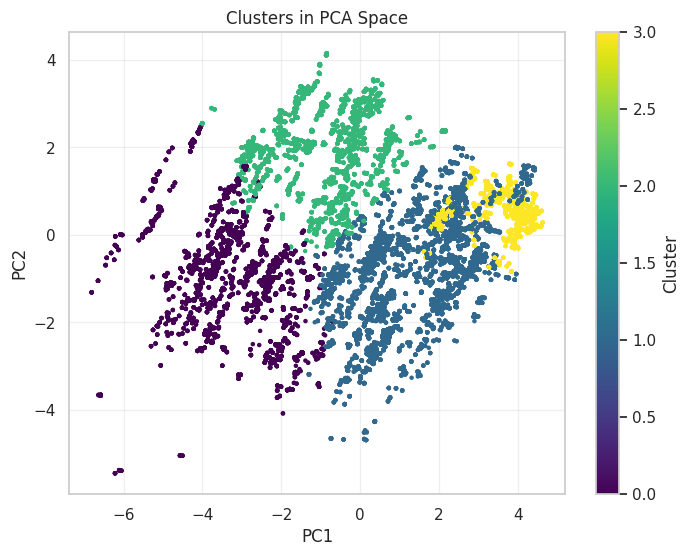

In [77]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=5)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

## Attach cluster labels to abundance data

This cell adds cluster assignments and the microbial abundance target back to the analysis table. This connection allows the unsupervised ecological states to be interpreted in relation to microbial abundance.

In [78]:
df_cluster_analysis = df_cluster.copy()
df_cluster_analysis["cluster"] = clusters
df_cluster_analysis["log_meanCopyNumber"] = df_model_ready["log_meanCopyNumber"]

print(df_cluster_analysis.shape)
display(df_cluster_analysis.head())

(26888, 18)


,soilInWaterpH_mean,soilInCaClpH_mean,soilMoisture_mean,dryMassFraction_mean,soilTemp,sampleTopDepth,sampleBottomDepth,airTemp_mean,precip_total,humidity_mean,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean,field_latitude,field_longitude,cluster,log_meanCopyNumber
0,4.321667,3.216667,1.118333,0.5665,7.4,0.0,5.0,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,0,0.0
1,4.321667,3.216667,1.118333,0.5665,7.4,5.0,31.0,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,0,0.0
2,4.321667,3.216667,1.118333,0.5665,6.4,20.0,30.0,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,0,0.0
3,4.321667,3.216667,1.118333,0.5665,6.4,0.0,20.0,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,0,0.0
4,4.321667,3.216667,1.118333,0.5665,5.9,0.0,17.0,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,0,0.0


## Kruskal Wallis test for abundance across clusters

This cell tests whether microbial abundance differs significantly across the discovered clusters. A non parametric test is appropriate because ecological abundance distributions may not follow normal assumptions even after transformation.

In [79]:
from scipy.stats import kruskal

groups = [
    df_cluster_analysis[df_cluster_analysis["cluster"] == i]["log_meanCopyNumber"]
    for i in sorted(df_cluster_analysis["cluster"].unique())
]

stat, p_value = kruskal(*groups)

print("Kruskal-Wallis Test (Abundance across clusters)")
print("Statistic:", stat)
print("p-value:", p_value)

Kruskal-Wallis Test (Abundance across clusters)
Statistic: 442.5738466429458
p-value: 1.3250162578564762e-95


## Save statistical test result

This cell stores the Kruskal-Wallis statistic and p-value in an exportable table. Saving the result makes the statistical interpretation traceable and reusable in the report or manuscript.

In [80]:
kw_results_df = pd.DataFrame({
    "Test": ["Kruskal-Wallis (Abundance vs Cluster)"],
    "Statistic": [stat],
    "p_value": [p_value]
})

display(kw_results_df)
kw_results_df.to_csv(TABLE_DIR / "kruskal_abundance_clusters.csv", index=False)

,Test,Statistic,p_value
0,Kruskal-Wallis (Abundance vs Cluster),442.573847,1.325016e-95


## Environmental variable tests across clusters

This cell applies non parametric tests to selected environmental variables across the cluster labels. The goal is to identify which ecological conditions distinguish the discovered states.

In [81]:
variables_to_test = [
    "soilTemp",
    "soilMoisture_mean",
    "soilInWaterpH_mean",
    "precip_total"
]

env_test_results = []

for var in variables_to_test:
    groups = [
        df_cluster_analysis[df_cluster_analysis["cluster"] == i][var]
        for i in sorted(df_cluster_analysis["cluster"].unique())
    ]

    stat, p_val = kruskal(*groups)

    env_test_results.append({
        "Variable": var,
        "Statistic": stat,
        "p_value": p_val
    })

env_test_df = pd.DataFrame(env_test_results)

display(env_test_df)
env_test_df.to_csv(TABLE_DIR / "kruskal_environment_clusters.csv", index=False)

,Variable,Statistic,p_value
0,soilTemp,16436.461612,0.0
1,soilMoisture_mean,9820.547194,0.0
2,soilInWaterpH_mean,11477.166315,0.0
3,precip_total,3119.853321,0.0


## Boxplot of abundance across clusters

This cell visualizes the distribution of microbial abundance within each cluster. The plot helps interpret whether statistically detected differences also appear as meaningful distributional separation.

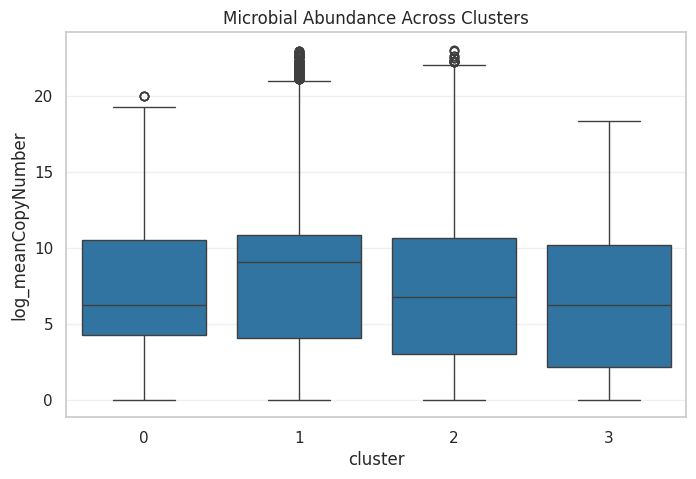

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster", y="log_meanCopyNumber", data=df_cluster_analysis)
plt.title("Microbial Abundance Across Clusters")
plt.savefig(FIG_DIR / "cluster_abundance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Final SHAP analysis for the fungi model

This cell creates SHAP values for the final fungi XGBoost model. SHAP is used because it explains individual and global model behaviour, helping connect predictions back to ecological variables rather than treating the model as a black box.

In [83]:
import shap

explainer_fungi_final = shap.Explainer(xgb_fungi_journal)
shap_values_fungi_final = explainer_fungi_final(X_test_f)

print("Computed SHAP values for fungi final model.")

Computed SHAP values for fungi final model.


## SHAP beeswarm plot

This cell generates a SHAP beeswarm plot for the fungi model. The plot summarizes both feature importance and the direction of feature effects, showing whether high or low feature values tend to increase predicted fungal abundance.

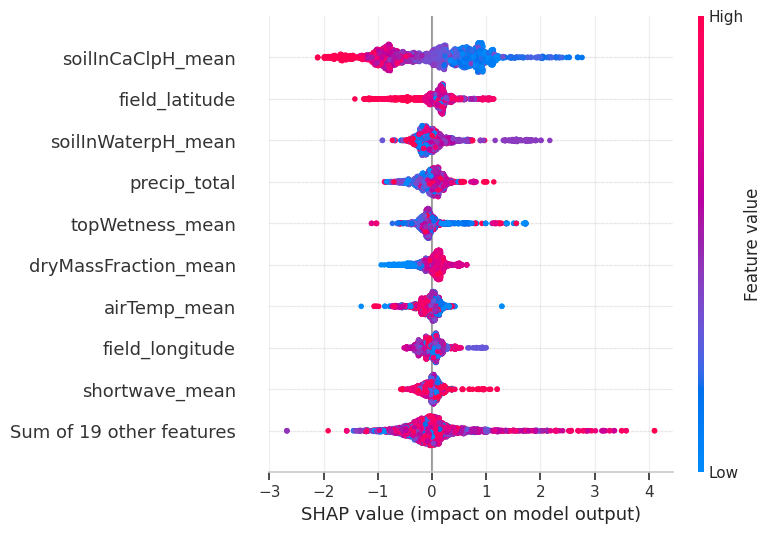

In [84]:
shap.plots.beeswarm(shap_values_fungi_final, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "final_fungi_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

## Methodological note

This short checkpoint adds context for the following code block. It clarifies why the step is included and how its output should be interpreted within the wider SoilMind modelling workflow.

## SHAP bar plot

This cell generates a global SHAP importance plot. The bar plot ranks variables by their average absolute contribution to predictions, making it easier to identify the strongest ecological drivers in the fungi model.

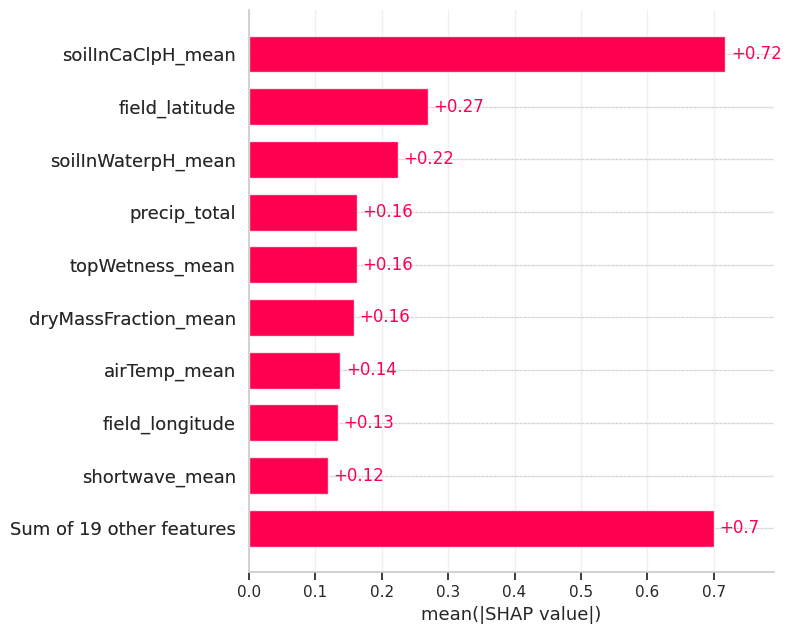

In [85]:
shap.plots.bar(shap_values_fungi_final, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "final_fungi_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## Mean absolute SHAP importance table

This cell exports a table of mean absolute SHAP values. The table provides a numeric companion to the SHAP bar plot and can be cited directly in the results section.

In [86]:
fungi_shap_importance_df = pd.DataFrame({
    "Feature": X_test_f.columns,
    "MeanAbsSHAP": np.abs(shap_values_fungi_final.values).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

display(fungi_shap_importance_df.head(20))
fungi_shap_importance_df.to_csv(TABLE_DIR / "final_fungi_shap_importance.csv", index=False)

,Feature,MeanAbsSHAP
1,soilInCaClpH_mean,0.717355
14,field_latitude,0.269373
0,soilInWaterpH_mean,0.224505
8,precip_total,0.162406
13,topWetness_mean,0.162087
3,dryMassFraction_mean,0.157383
7,airTemp_mean,0.137657
15,field_longitude,0.133679
10,shortwave_mean,0.118586
9,humidity_mean,0.115741


## SHAP dependence plots for top features

This cell identifies the top SHAP ranked features and generates dependence plots for them. These plots help interpret whether a feature has a linear, threshold like, or interaction-driven relationship with predicted fungal abundance.

In [87]:
top3_fungi_features = fungi_shap_importance_df["Feature"].head(3).tolist()
print("Top 3 fungi SHAP features:", top3_fungi_features)

Top 3 fungi SHAP features: ['soilInCaClpH_mean', 'field_latitude', 'soilInWaterpH_mean']


## Generate dependence plots for selected SHAP features

This cell performs the `Generate dependence plots for selected SHAP features` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

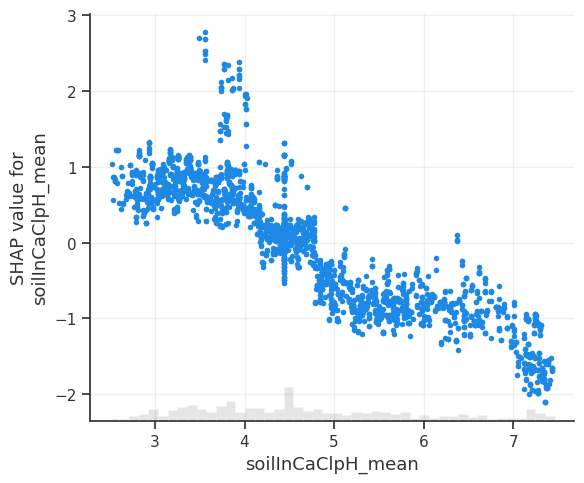

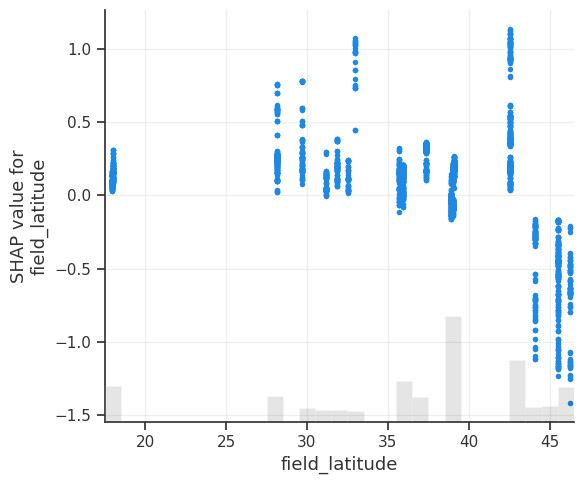

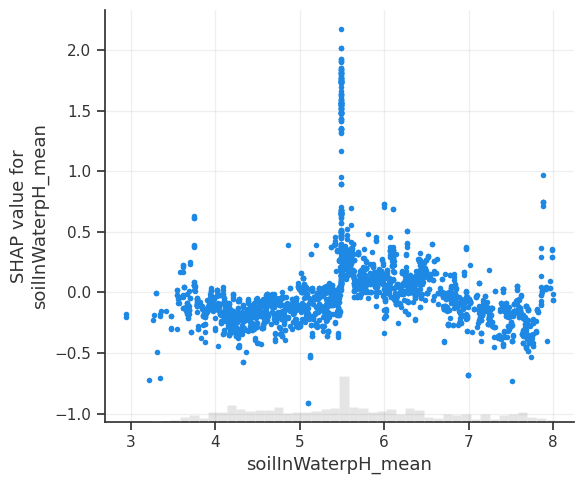

In [88]:
for feat in top3_fungi_features:
    shap.plots.scatter(shap_values_fungi_final[:, feat], show=False)
    plt.tight_layout()
    safe_name = feat.replace("/", "_").replace(" ", "_")
    plt.savefig(FIG_DIR / f"final_fungi_shap_dependence_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Define ablation feature groups

This cell organizes predictors into interpretable ecological groups such as soil, climate, spatial, temporal, and land cover variables. Grouping features this way allows the analysis to test how much each source of information contributes to predictive performance.

In [89]:
target = "log_meanCopyNumber"

soil_features = [
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "horizon"
]

climate_features = [
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean"
]

spatial_features = [
    "field_latitude",
    "field_longitude"
]

temporal_features = [
    "month",
    "season"
]

context_features = [
    "crop_type"
]

ablation_feature_sets = {
    "Soil only": soil_features,
    "Climate only": climate_features,
    "Soil + Climate": soil_features + climate_features,
    "Soil + Climate + Spatial": soil_features + climate_features + spatial_features,
    "Soil + Climate + Spatial + Temporal": soil_features + climate_features + spatial_features + temporal_features,
    "Full Ecological Set": soil_features + climate_features + spatial_features + temporal_features + context_features
}

for name, feats in ablation_feature_sets.items():
    print(name, "->", len(feats), "raw features")

Soil only -> 8 raw features
Climate only -> 7 raw features
Soil + Climate -> 15 raw features
Soil + Climate + Spatial -> 17 raw features
Soil + Climate + Spatial + Temporal -> 19 raw features
Full Ecological Set -> 20 raw features


## Ablation modelling function

This cell defines a reusable function for training and evaluating XGBoost models on different feature subsets. A common function ensures that ablation results are comparable because the same modelling and evaluation logic is applied to each feature group.

In [90]:
def run_ablation_model(df_source, feature_list, target_col, seed=42):
    cols = [c for c in feature_list + [target_col] if c in df_source.columns]
    df_ab = df_source[cols].copy()

    df_ab_encoded = pd.get_dummies(df_ab, drop_first=True)

    X_ab = df_ab_encoded.drop(columns=[target_col])
    y_ab = df_ab_encoded[target_col]

    X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
        X_ab, y_ab, test_size=0.2, random_state=seed
    )

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train_ab, y_train_ab)
    y_pred_ab = model.predict(X_test_ab)

    return {
        "n_features_encoded": X_ab.shape[1],
        "R2": r2_score(y_test_ab, y_pred_ab),
        "MAE": mean_absolute_error(y_test_ab, y_pred_ab),
        "RMSE": np.sqrt(mean_squared_error(y_test_ab, y_pred_ab))
    }

## Run ablation study on the global ecological dataset

This cell evaluates model performance for each predefined feature group. The ablation study helps determine whether prediction depends mainly on one source of information or on the integration of multiple ecological modalities.

In [91]:
ablation_results = []

for set_name, feats in ablation_feature_sets.items():
    result = run_ablation_model(
        df_source=df_model_ready,
        feature_list=feats,
        target_col=target,
        seed=SEED
    )

    ablation_results.append({
        "Feature_Set": set_name,
        "Encoded_Features": result["n_features_encoded"],
        "R2": result["R2"],
        "MAE": result["MAE"],
        "RMSE": result["RMSE"]
    })

ablation_df = pd.DataFrame(ablation_results).sort_values(by="R2", ascending=False)

display(ablation_df)
ablation_df.to_csv(TABLE_DIR / "ablation_study_results.csv", index=False)

,Feature_Set,Encoded_Features,R2,MAE,RMSE
1,Climate only,7,0.253696,3.568573,3.989672
5,Full Ecological Set,28,0.179010,3.740465,4.184545
4,Soil + Climate + Spatial + Temporal,21,0.176934,3.744335,4.189832
3,Soil + Climate + Spatial,17,0.176862,3.744695,4.190015
2,Soil + Climate,15,0.175849,3.748157,4.192594
0,Soil only,8,0.158311,3.795218,4.236967


## Plot ablation-study performance

This cell visualizes R² across the ablation feature sets. The figure makes it easier to compare the contribution of soil, climate, spatial, temporal, and combined predictors.

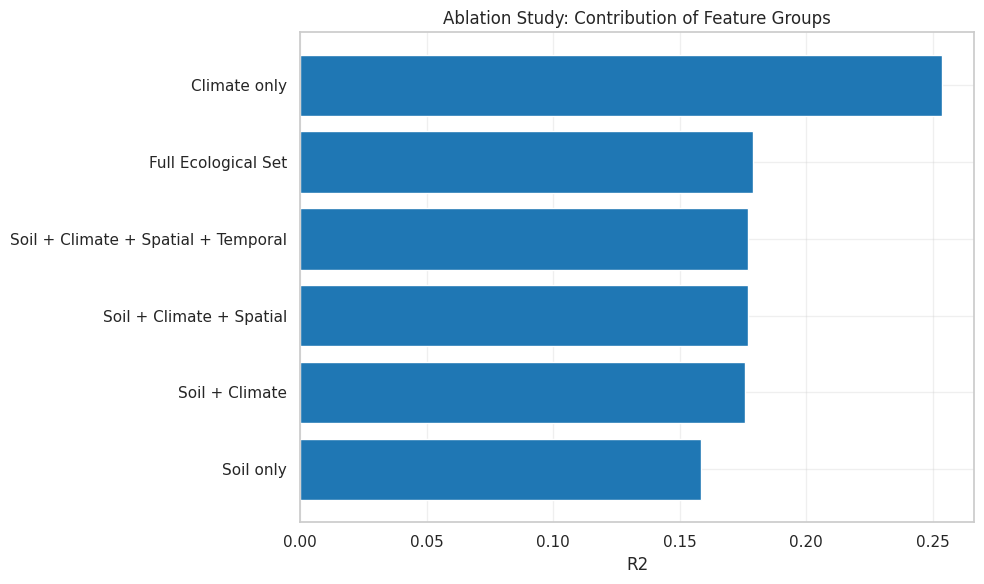

In [92]:
plt.figure(figsize=(10, 6))
plt.barh(ablation_df["Feature_Set"][::-1], ablation_df["R2"][::-1])
plt.xlabel("R2")
plt.title("Ablation Study: Contribution of Feature Groups")
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_study_r2.png", dpi=300, bbox_inches="tight")
plt.show()

## Ordered ablation table for reporting

This cell arranges the ablation results in a meaningful order for paper presentation. Ordering the rows by conceptual feature groups improves readability compared with a purely alphabetical or execution-order table.

In [93]:
ordered_names = [
    "Soil only",
    "Climate only",
    "Soil + Climate",
    "Soil + Climate + Spatial",
    "Soil + Climate + Spatial + Temporal",
    "Full Ecological Set"
]

ablation_ordered_df = pd.DataFrame(ablation_results)
ablation_ordered_df["Feature_Set"] = pd.Categorical(
    ablation_ordered_df["Feature_Set"],
    categories=ordered_names,
    ordered=True
)
ablation_ordered_df = ablation_ordered_df.sort_values("Feature_Set")

display(ablation_ordered_df)
ablation_ordered_df.to_csv(TABLE_DIR / "ablation_study_results_ordered.csv", index=False)

,Feature_Set,Encoded_Features,R2,MAE,RMSE
0,Soil only,8,0.158311,3.795218,4.236967
1,Climate only,7,0.253696,3.568573,3.989672
2,Soil + Climate,15,0.175849,3.748157,4.192594
3,Soil + Climate + Spatial,17,0.176862,3.744695,4.190015
4,Soil + Climate + Spatial + Temporal,21,0.176934,3.744335,4.189832
5,Full Ecological Set,28,0.179010,3.740465,4.184545


## Define feature governance categories

This cell documents how variables are classified into target, ecological predictors, metadata, and excluded feature groups. This governance table is important for transparency because it explains which columns are used for modelling and which are excluded to avoid leakage or weak interpretability.

In [94]:
feature_governance = [
    {
        "Category": "Target Variable",
        "Description": "Final prediction target used for modeling",
        "Columns": ["log_meanCopyNumber"]
    },
    {
        "Category": "Soil Features",
        "Description": "Soil chemistry and physical properties",
        "Columns": [
            "soilInWaterpH_mean",
            "soilInCaClpH_mean",
            "soilMoisture_mean",
            "dryMassFraction_mean",
            "soilTemp",
            "sampleTopDepth",
            "sampleBottomDepth",
            "horizon"
        ]
    },
    {
        "Category": "Climate Features",
        "Description": "Environmental and meteorological variables",
        "Columns": [
            "airTemp_mean",
            "precip_total",
            "humidity_mean",
            "shortwave_mean",
            "par_mean",
            "surfaceTemp_mean",
            "topWetness_mean"
        ]
    },
    {
        "Category": "Spatial Features",
        "Description": "Geographic location variables",
        "Columns": [
            "field_latitude",
            "field_longitude"
        ]
    },
    {
        "Category": "Temporal Features",
        "Description": "Time-related variables derived from collection date",
        "Columns": [
            "month",
            "season"
        ]
    },
    {
        "Category": "Contextual Features",
        "Description": "Land use / vegetation type",
        "Columns": [
            "crop_type"
        ]
    },
    {
        "Category": "Excluded Identifier Columns",
        "Description": "Removed to prevent data leakage and non-generalizable patterns",
        "Columns": [
            "uid_x", "uid_y",
            "siteID", "siteID_x",
            "plotID", "plotID_x",
            "geneticSampleID",
            "internalLabID_x",
            "laboratoryName_x",
            "processedBy",
            "reviewedBy"
        ]
    },
    {
        "Category": "Dropped Metadata / High-Missing Columns",
        "Description": "Removed due to high missingness or irrelevance",
        "Columns": [
            "nucleicAcidPurity",
            "deprecatedVialID",
            "dataQF_x", "dataQF_y",
            "remarks_x", "remarks_y",
            "dnaSampleCode"
        ]
    },
    {
        "Category": "Subgroup Split Variable",
        "Description": "Used only for splitting dataset (not as model input)",
        "Columns": [
            "targetTaxonGroup"
        ]
    }
]

## Convert feature governance rules to a table

This cell converts the feature-governance specification into a DataFrame. The table format makes the variable-use policy easy to export, review, and include in the methodology or appendix.

In [95]:
gov_rows = []

for item in feature_governance:
    gov_rows.append({
        "Category": item["Category"],
        "Description": item["Description"],
        "Columns": ", ".join(item["Columns"])
    })

feature_governance_df = pd.DataFrame(gov_rows)

display(feature_governance_df)
feature_governance_df.to_csv(TABLE_DIR / "feature_governance_table.csv", index=False)

,Category,Description,Columns
0,Target Variable,Final prediction target used for modeling,log_meanCopyNumber
1,Soil Features,Soil chemistry and physical properties,"soilInWaterpH_mean, soilInCaClpH_mean, soilMoi..."
2,Climate Features,Environmental and meteorological variables,"airTemp_mean, precip_total, humidity_mean, sho..."
3,Spatial Features,Geographic location variables,"field_latitude, field_longitude"
4,Temporal Features,Time-related variables derived from collection...,"month, season"
5,Contextual Features,Land use / vegetation type,crop_type
6,Excluded Identifier Columns,Removed to prevent data leakage and non-genera...,"uid_x, uid_y, siteID, siteID_x, plotID, plotID..."
7,Dropped Metadata / High-Missing Columns,Removed due to high missingness or irrelevance,"nucleicAcidPurity, deprecatedVialID, dataQF_x,..."
8,Subgroup Split Variable,Used only for splitting dataset (not as model ...,targetTaxonGroup


## Count columns per governance category

This cell adds a count of variables in each governance category. The count gives a compact summary of how much information comes from each feature source and supports clear reporting of the modelling design.

In [96]:
feature_governance_df["Num_Columns"] = feature_governance_df["Columns"].apply(
    lambda x: len(x.split(", "))
)

display(feature_governance_df)

,Category,Description,Columns,Num_Columns
0,Target Variable,Final prediction target used for modeling,log_meanCopyNumber,1
1,Soil Features,Soil chemistry and physical properties,"soilInWaterpH_mean, soilInCaClpH_mean, soilMoi...",8
2,Climate Features,Environmental and meteorological variables,"airTemp_mean, precip_total, humidity_mean, sho...",7
3,Spatial Features,Geographic location variables,"field_latitude, field_longitude",2
4,Temporal Features,Time-related variables derived from collection...,"month, season",2
5,Contextual Features,Land use / vegetation type,crop_type,1
6,Excluded Identifier Columns,Removed to prevent data leakage and non-genera...,"uid_x, uid_y, siteID, siteID_x, plotID, plotID...",11
7,Dropped Metadata / High-Missing Columns,Removed due to high missingness or irrelevance,"nucleicAcidPurity, deprecatedVialID, dataQF_x,...",7
8,Subgroup Split Variable,Used only for splitting dataset (not as model ...,targetTaxonGroup,1


## Freeze baseline benchmarks for AI extension

This section freezes the ecological benchmark outputs before representation learning experiments begin. Freezing the baseline prevents later experimental changes from silently shifting the comparison point and makes the representation learning extension more scientifically defensible.

In [97]:
baseline_benchmark_summary = pd.DataFrame([
    {
        "Task": "Global",
        "Validation": "Random Split",
        "Model": "XGBoost",
        "R2": xgb_r2,
        "MAE": xgb_mae,
        "RMSE": xgb_rmse
    },
    {
        "Task": "Global",
        "Validation": "5-Fold CV Mean",
        "Model": "XGBoost",
        "R2": kf_results_df["R2"].mean(),
        "MAE": kf_results_df["MAE"].mean(),
        "RMSE": kf_results_df["RMSE"].mean()
    },
    {
        "Task": "Global",
        "Validation": "GroupKFold by Site Mean",
        "Model": "XGBoost",
        "R2": gkf_results_df["R2"].mean() if site_group_col is not None else np.nan,
        "MAE": gkf_results_df["MAE"].mean() if site_group_col is not None else np.nan,
        "RMSE": gkf_results_df["RMSE"].mean() if site_group_col is not None else np.nan
    },
    {
        "Task": "Global",
        "Validation": "Time-Aware Holdout",
        "Model": "XGBoost",
        "R2": time_results.loc[0, "R2"] if "time_results" in globals() else np.nan,
        "MAE": time_results.loc[0, "MAE"] if "time_results" in globals() else np.nan,
        "RMSE": time_results.loc[0, "RMSE"] if "time_results" in globals() else np.nan
    },
    {
        "Task": "Fungi",
        "Validation": "Random Split",
        "Model": "XGBoost",
        "R2": fungi_random_results.loc[0, "R2"],
        "MAE": fungi_random_results.loc[0, "MAE"],
        "RMSE": fungi_random_results.loc[0, "RMSE"]
    },
    {
        "Task": "Fungi",
        "Validation": "5-Fold CV Mean",
        "Model": "XGBoost",
        "R2": fungi_kf_df["R2"].mean(),
        "MAE": fungi_kf_df["MAE"].mean(),
        "RMSE": fungi_kf_df["RMSE"].mean()
    },
    {
        "Task": "Fungi",
        "Validation": "GroupKFold by Site Mean",
        "Model": "XGBoost",
        "R2": fungi_gkf_df["R2"].mean() if "fungi_gkf_df" in globals() else np.nan,
        "MAE": fungi_gkf_df["MAE"].mean() if "fungi_gkf_df" in globals() else np.nan,
        "RMSE": fungi_gkf_df["RMSE"].mean() if "fungi_gkf_df" in globals() else np.nan
    },
    {
        "Task": "Fungi",
        "Validation": "Time-Aware Holdout",
        "Model": "XGBoost",
        "R2": fungi_time_results.loc[0, "R2"] if "fungi_time_results" in globals() else np.nan,
        "MAE": fungi_time_results.loc[0, "MAE"] if "fungi_time_results" in globals() else np.nan,
        "RMSE": fungi_time_results.loc[0, "RMSE"] if "fungi_time_results" in globals() else np.nan
    },
    {
        "Task": "Bacteria/Archaea",
        "Validation": "Random Split",
        "Model": "XGBoost",
        "R2": bact_random_results.loc[0, "R2"],
        "MAE": bact_random_results.loc[0, "MAE"],
        "RMSE": bact_random_results.loc[0, "RMSE"]
    },
    {
        "Task": "Bacteria/Archaea",
        "Validation": "5-Fold CV Mean",
        "Model": "XGBoost",
        "R2": bact_kf_df["R2"].mean(),
        "MAE": bact_kf_df["MAE"].mean(),
        "RMSE": bact_kf_df["RMSE"].mean()
    },
    {
        "Task": "Bacteria/Archaea",
        "Validation": "GroupKFold by Site Mean",
        "Model": "XGBoost",
        "R2": bact_gkf_df["R2"].mean() if "bact_gkf_df" in globals() else np.nan,
        "MAE": bact_gkf_df["MAE"].mean() if "bact_gkf_df" in globals() else np.nan,
        "RMSE": bact_gkf_df["RMSE"].mean() if "bact_gkf_df" in globals() else np.nan
    },
    {
        "Task": "Bacteria/Archaea",
        "Validation": "Time-Aware Holdout",
        "Model": "XGBoost",
        "R2": bact_time_results.loc[0, "R2"] if "bact_time_results" in globals() else np.nan,
        "MAE": bact_time_results.loc[0, "MAE"] if "bact_time_results" in globals() else np.nan,
        "RMSE": bact_time_results.loc[0, "RMSE"] if "bact_time_results" in globals() else np.nan
    }
])

display(baseline_benchmark_summary)
baseline_benchmark_summary.to_csv(TABLE_DIR / "baseline_benchmark_summary.csv", index=False)
print("Saved baseline benchmark summary.")


,Task,Validation,Model,R2,MAE,RMSE
0,Global,Random Split,XGBoost,0.179010,3.740465,4.184545
1,Global,5-Fold CV Mean,XGBoost,0.200111,3.709303,4.148934
2,Global,GroupKFold by Site Mean,XGBoost,-0.140480,4.077684,4.859699
3,Global,Time-Aware Holdout,XGBoost,-0.114325,2.687802,3.022069
4,Fungi,Random Split,XGBoost,0.622916,0.887994,1.583214
5,Fungi,5-Fold CV Mean,XGBoost,0.646196,0.876902,1.524902
6,Fungi,GroupKFold by Site Mean,XGBoost,-0.073063,1.742322,2.509095
7,Fungi,Time-Aware Holdout,XGBoost,-0.883874,1.512638,1.814517
8,Bacteria/Archaea,Random Split,XGBoost,0.368059,1.295154,2.897180
9,Bacteria/Archaea,5-Fold CV Mean,XGBoost,0.403444,1.255366,2.800692


Saved baseline benchmark summary.


## Save the frozen feature manifest

This cell performs the `Save the frozen feature manifest` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

In [98]:
baseline_feature_manifest = {
    "target": target,
    "ecological_features": ecological_features,
    "global_X_columns": list(X.columns),
    "fungi_X_columns": list(X_fungi.columns),
    "bacteria_archaea_X_columns": list(X_bact.columns),
    "site_group_col_global": site_group_col,
    "year_col_global": year_col,
    "site_group_col_fungi": fungi_site_group_col,
    "year_col_fungi": fungi_year_col,
    "site_group_col_bacteria_archaea": bact_site_group_col,
    "year_col_bacteria_archaea": bact_year_col,
    "seed": SEED
}

with open(DATA_DIR / "baseline_feature_manifest.json", "w") as f:
    json.dump(baseline_feature_manifest, f, indent=2)

print("Saved baseline feature manifest.")


Saved baseline feature manifest.


## Save frozen modelling datasets

This cell performs the `Save frozen modelling datasets` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

In [99]:
baseline_frozen_datasets = {
    "global_model_ready": df_model_ready,
    "fungi_model_ready": fungi_model_df,
    "bacteria_archaea_model_ready": bact_model_df,
    "global_encoded_X": X,
    "global_target_y": y,
    "fungi_encoded_X": X_fungi,
    "fungi_target_y": y_fungi,
    "bacteria_archaea_encoded_X": X_bact,
    "bacteria_archaea_target_y": y_bact
}

with open(DATA_DIR / "baseline_frozen_datasets.pkl", "wb") as f:
    pickle.dump(baseline_frozen_datasets, f)

print("Saved frozen datasets for future AI-layer experiments.")


Saved frozen datasets for future AI-layer experiments.


## Save the validation split manifest

This cell performs the `Save the validation split manifest` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation learning stage rather than as an isolated calculation.

In [100]:
baseline_split_manifest = {
    "global_random_split": {
        "test_size": 0.2,
        "random_state": SEED
    },
    "global_groupkfold": {
        "n_splits": 5,
        "group_column": site_group_col
    },
    "global_time_holdout": {
        "year_column": year_col,
        "test_year": int(test_year) if "test_year" in globals() else None
    },
    "fungi_random_split": {
        "test_size": 0.2,
        "random_state": SEED
    },
    "fungi_groupkfold": {
        "n_splits": 5,
        "group_column": fungi_site_group_col
    },
    "fungi_time_holdout": {
        "year_column": fungi_year_col,
        "test_year": int(fungi_test_year) if "fungi_test_year" in globals() else None
    },
    "bacteria_archaea_random_split": {
        "test_size": 0.2,
        "random_state": SEED
    },
    "bacteria_archaea_groupkfold": {
        "n_splits": 5,
        "group_column": bact_site_group_col
    },
    "bacteria_archaea_time_holdout": {
        "year_column": bact_year_col,
        "test_year": int(bact_test_year) if "bact_test_year" in globals() else None
    }
}

with open(DATA_DIR / "baseline_split_manifest.json", "w") as f:
    json.dump(baseline_split_manifest, f, indent=2)

print("Saved split manifest for baseline comparability.")


Saved split manifest for baseline comparability.


## Baseline comparison on the random split

This cell places Ridge, Random Forest, and XGBoost results side by side. The comparison helps identify whether predictive gains come from nonlinear modelling capacity, ensemble learning, or regularized linear structure.

In [101]:
pip install numpy pandas matplotlib torch scikit-learn xgboost

## Import neural-network dependencies for representation learning

This cell performs the `Import neural-network dependencies for representation learning` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

In [102]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch device:", DEVICE)


Torch device: cpu


## Build the fungi representation-learning source table

This cell rebuilds the fungi modelling table for representation learning. The fungi subset is used because subgroup-specific modelling provides a focused test of whether latent ecological embeddings can capture meaningful microbial environment structure.

In [103]:
fungi_repr_source = fungi_df.copy()

site_col = "siteID" if "siteID" in fungi_repr_source.columns else "siteID_x"
year_col = "year"

print("Using site column:", site_col)
print("Using year column:", year_col)

fungi_site_meta = fungi_repr_source[site_col].astype(str).reset_index(drop=True)
fungi_year_meta = fungi_repr_source[year_col].astype(int).reset_index(drop=True)

exclude_cols_repr = [
    target,
    "siteID", "siteID_x",
    "plotID", "plotID_x",
    "collectDate",
    "year_month",
    "year_month_parsed",
    "year_from_date"
]
exclude_cols_repr = [c for c in exclude_cols_repr if c in fungi_repr_source.columns]

fungi_repr_features = fungi_repr_source.drop(columns=exclude_cols_repr).copy()

# Drop any remaining datetime columns
datetime_cols = fungi_repr_features.select_dtypes(
    include=["datetime64[ns]", "datetime64[ns, UTC]", "datetimetz"]
).columns.tolist()

if len(datetime_cols) > 0:
    print("Dropping datetime columns:", datetime_cols)
    fungi_repr_features = fungi_repr_features.drop(columns=datetime_cols)

fungi_repr_encoded = pd.get_dummies(fungi_repr_features, drop_first=True)

X_fungi_repr = fungi_repr_encoded.reset_index(drop=True).copy()
y_fungi_repr = fungi_repr_source[target].reset_index(drop=True).copy()

print("Fungi representation source shape:", fungi_repr_source.shape)
print("Feature matrix shape:", X_fungi_repr.shape)
print("Target shape:", y_fungi_repr.shape)
display(X_fungi_repr.head())


Using site column: siteID
Using year column: year
Dropping datetime columns: ['collectDate_x']
Fungi representation source shape: (13074, 62)
Feature matrix shape: (13074, 11677)
Target shape: (13074,)


,nucleicAcidConcentration_x,meanCopyNumber,copyNumberStandardDeviation,meanCqValue,sampleMass,year,crop_code,soilInWaterpH_mean,soilInWaterpH_std,soilInWaterpH_n,...,crop_type_Grass/Pasture,crop_type_Mixed Forest,crop_type_Shrubland,crop_type_Unknown,crop_type_Winter Wheat,crop_type_Woody Wetlands,horizon_O,season_Spring,season_Summer,season_Winter
0,6.7,0.0,0.0,20.7,0.25,2014.0,143.0,4.321667,0.220583,6.0,...,False,True,False,False,False,False,True,False,False,False
1,6.7,0.0,0.0,20.7,0.25,2014.0,143.0,4.321667,0.220583,6.0,...,False,True,False,False,False,False,False,False,False,False
2,6.7,0.0,0.0,20.7,0.25,2014.0,143.0,4.321667,0.220583,6.0,...,False,True,False,False,False,False,False,False,False,False
3,6.7,0.0,0.0,20.7,0.25,2014.0,143.0,4.321667,0.220583,6.0,...,False,True,False,False,False,False,True,False,False,False
4,6.7,0.0,0.0,20.7,0.25,2014.0,143.0,4.321667,0.220583,6.0,...,False,True,False,False,False,False,True,False,False,False


## Random split for the first representation-learning benchmark

This cell creates a random split for the initial autoencoder benchmark. This first split allows raw features, latent embeddings, and combined features to be compared under a familiar setting before moving to stricter validation.

In [104]:
Xf_train_df, Xf_test_df, yf_train, yf_test, site_train, site_test, year_train, year_test = train_test_split(
    X_fungi_repr,
    y_fungi_repr,
    fungi_site_meta,
    fungi_year_meta,
    test_size=0.2,
    random_state=SEED
)

print("Train shape:", Xf_train_df.shape)
print("Test shape :", Xf_test_df.shape)


Train shape: (10459, 11677)
Test shape : (2615, 11677)


## Standardize inputs for the autoencoder

This cell fits a scaler on the training data and applies it to the test data. Scaling is required for neural representation learning because unscaled ecological variables could dominate the reconstruction loss simply because of their measurement units.

In [105]:
repr_scaler = StandardScaler()

Xf_train_scaled = repr_scaler.fit_transform(Xf_train_df)
Xf_test_scaled = repr_scaler.transform(Xf_test_df)

input_dim = Xf_train_scaled.shape[1]
print("Input dimension:", input_dim)


Input dimension: 11677


## Define the ecological autoencoder

This cell defines a compact neural autoencoder that compresses ecological features into a lower-dimensional latent representation. The design tests whether the model can learn a structured ecological embedding that summarizes the original predictors while removing some redundancy.

In [106]:
class EcologicalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


## Train the autoencoder

This cell creates PyTorch data loaders and trains the autoencoder using reconstruction loss. The validation loss is monitored to check whether the learned representation generalizes to unseen samples rather than only memorizing the training matrix.

In [107]:
batch_size = 256

train_tensor = torch.tensor(Xf_train_scaled, dtype=torch.float32)
test_tensor = torch.tensor(Xf_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=batch_size, shuffle=False)

latent_dim = 16
ae_model = EcologicalAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

epochs = 80
best_state = None
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(epochs):
    ae_model.train()
    running_train = 0.0

    for (xb,) in train_loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad()
        x_hat, _ = ae_model(xb)
        loss = criterion(x_hat, xb)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    train_loss = running_train / len(train_loader.dataset)
    train_losses.append(train_loss)

    ae_model.eval()
    running_val = 0.0
    with torch.no_grad():
        for (xb,) in test_loader:
            xb = xb.to(DEVICE)
            x_hat, _ = ae_model(xb)
            loss = criterion(x_hat, xb)
            running_val += loss.item() * xb.size(0)

    val_loss = running_val / len(test_loader.dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(ae_model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

ae_model.load_state_dict(best_state)
print("Best validation reconstruction loss:", best_val_loss)


Epoch 001 | train_loss=0.984952 | val_loss=1.400870
Epoch 010 | train_loss=0.960895 | val_loss=1.380971
Epoch 020 | train_loss=0.952581 | val_loss=1.374858
Epoch 030 | train_loss=0.948990 | val_loss=1.372237
Epoch 040 | train_loss=0.946883 | val_loss=1.370687
Epoch 050 | train_loss=0.945505 | val_loss=1.369677
Epoch 060 | train_loss=0.944392 | val_loss=1.368767
Epoch 070 | train_loss=0.943556 | val_loss=1.368052
Epoch 080 | train_loss=0.942716 | val_loss=1.367166
Best validation reconstruction loss: 1.3671658725629117


## Plot autoencoder reconstruction curves

This cell plots training and validation reconstruction loss across epochs. A stable decrease in both curves indicates that the autoencoder is learning useful structure, while divergence between them would suggest overfitting.

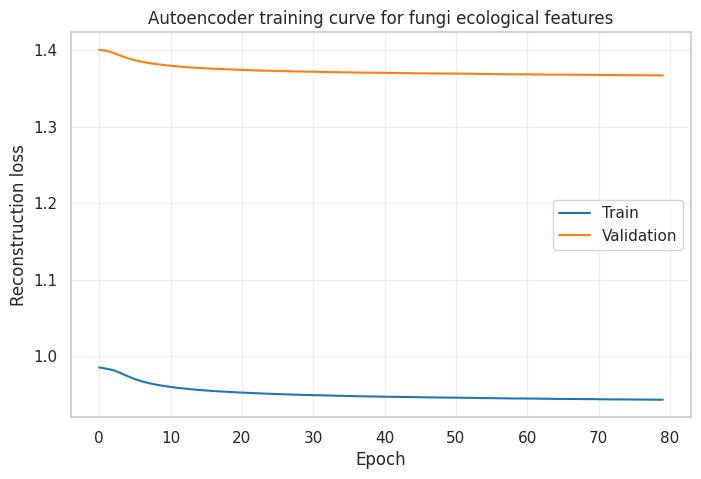

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Autoencoder training curve for fungi ecological features")
plt.legend()
plt.show()


## Extract latent ecological embeddings

This cell uses the trained encoder to transform raw ecological features into latent vectors. These embeddings become an alternative feature view for downstream XGBoost prediction, allowing direct comparison between raw, latent, and hybrid representations.

In [109]:
def encode_with_autoencoder(model, X_scaled):
    model.eval()
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        _, z = model(X_tensor)
    return z.cpu().numpy()

Zf_train = encode_with_autoencoder(ae_model, Xf_train_scaled)
Zf_test = encode_with_autoencoder(ae_model, Xf_test_scaled)

latent_cols = [f"latent_{i}" for i in range(Zf_train.shape[1])]

Zf_train_df = pd.DataFrame(Zf_train, columns=latent_cols, index=Xf_train_df.index)
Zf_test_df = pd.DataFrame(Zf_test, columns=latent_cols, index=Xf_test_df.index)

print("Latent train shape:", Zf_train_df.shape)
print("Latent test shape :", Zf_test_df.shape)


Latent train shape: (10459, 16)
Latent test shape : (2615, 16)


## Baseline comparison on the random split

This cell places Ridge, Random Forest, and XGBoost results side by side. The comparison helps identify whether predictive gains come from nonlinear modelling capacity, ensemble learning, or regularized linear structure.

In [110]:
Xf_train_raw = Xf_train_df.copy()
Xf_test_raw = Xf_test_df.copy()

Xf_train_latent = Zf_train_df.copy()
Xf_test_latent = Zf_test_df.copy()

raw_feature_limit = 200

top_raw_cols = Xf_train_raw.columns[:raw_feature_limit].tolist()

Xf_train_raw_small = Xf_train_raw[top_raw_cols].copy()
Xf_test_raw_small = Xf_test_raw[top_raw_cols].copy()

Xf_train_raw_latent_small = pd.concat(
    [Xf_train_raw_small.reset_index(drop=True), Xf_train_latent.reset_index(drop=True)],
    axis=1
)
Xf_test_raw_latent_small = pd.concat(
    [Xf_test_raw_small.reset_index(drop=True), Xf_test_latent.reset_index(drop=True)],
    axis=1
)

print("Reduced raw shape:", Xf_train_raw_small.shape)
print("Latent shape:", Xf_train_latent.shape)
print("Reduced raw + latent shape:", Xf_train_raw_latent_small.shape)

def evaluate_xgb_once(X_train, X_test, y_train, y_test, seed=42):
    model = XGBRegressor(
        n_estimators=60,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=1,
        tree_method="hist"
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": math.sqrt(mean_squared_error(y_test, preds)),
        "model": model,
        "preds": preds
    }

repr_random_results = []
repr_models_random = {}

feature_views_random = {
    "Raw ecological features (reduced)": (Xf_train_raw_small, Xf_test_raw_small),
    "Latent ecological representation": (Xf_train_latent, Xf_test_latent),
    "Raw + latent features (reduced)": (Xf_train_raw_latent_small, Xf_test_raw_latent_small),
}

for view_name, (Xtr, Xte) in feature_views_random.items():
    print("Running:", view_name, "| shape:", Xtr.shape)
    result = evaluate_xgb_once(Xtr, Xte, yf_train, yf_test, seed=SEED)
    repr_models_random[view_name] = result["model"]
    repr_random_results.append({
        "Feature_View": view_name,
        "R2": round(result["R2"], 4),
        "MAE": round(result["MAE"], 4),
        "RMSE": round(result["RMSE"], 4)
    })

repr_random_df = pd.DataFrame(repr_random_results).sort_values("R2", ascending=False)
display(repr_random_df)


Reduced raw shape: (10459, 200)
Latent shape: (10459, 16)
Reduced raw + latent shape: (10459, 216)
Running: Raw ecological features (reduced) | shape: (10459, 200)
Running: Latent ecological representation | shape: (10459, 16)
Running: Raw + latent features (reduced) | shape: (10459, 216)


,Feature_View,R2,MAE,RMSE
0,Raw ecological features (reduced),0.9942,0.1375,0.1965
2,Raw + latent features (reduced),0.9919,0.1701,0.2323
1,Latent ecological representation,0.4757,1.3463,1.8669


## Compare representation-learning results with the frozen fungi baseline

This cell compares the new representation-learning outputs against the previously frozen fungi benchmark. This prevents accidental moving targets and makes the evaluation of representation learning more rigorous.

In [111]:
if "baseline_benchmark_summary" in globals():
    fungi_baseline_rows = baseline_benchmark_summary[
        baseline_benchmark_summary["Task"].astype(str).str.lower() == "fungi"
    ].copy()
    display(fungi_baseline_rows)
else:
    print("baseline_benchmark_summary not found. The frozen benchmark section must be run first.")

print("Representation-learning random split comparison:")
display(repr_random_df)


,Task,Validation,Model,R2,MAE,RMSE
4,Fungi,Random Split,XGBoost,0.622916,0.887994,1.583214
5,Fungi,5-Fold CV Mean,XGBoost,0.646196,0.876902,1.524902
6,Fungi,GroupKFold by Site Mean,XGBoost,-0.073063,1.742322,2.509095
7,Fungi,Time-Aware Holdout,XGBoost,-0.883874,1.512638,1.814517


Representation-learning random split comparison:


,Feature_View,R2,MAE,RMSE
0,Raw ecological features (reduced),0.9942,0.1375,0.1965
2,Raw + latent features (reduced),0.9919,0.1701,0.2323
1,Latent ecological representation,0.4757,1.3463,1.8669


## Visualize the latent ecological space

This cell projects the learned latent embeddings into two PCA dimensions and colors them by abundance. The visualization helps assess whether the autoencoder representation organizes samples along gradients related to microbial abundance.

Explained variance ratio: [0.13996734 0.12259996]


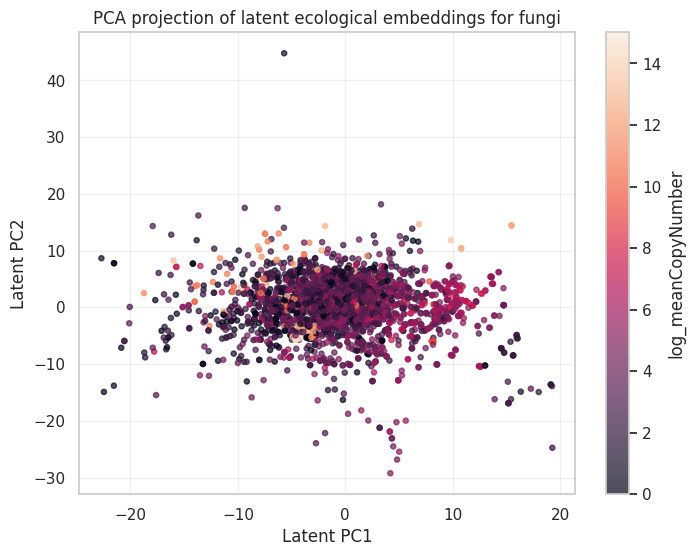

In [112]:
pca_latent = PCA(n_components=2, random_state=SEED)

Zf_train_pca = pca_latent.fit_transform(Zf_train)
Zf_test_pca = pca_latent.transform(Zf_test)

latent_vis_test = pd.DataFrame({
    "PC1": Zf_test_pca[:, 0],
    "PC2": Zf_test_pca[:, 1],
    "log_meanCopyNumber": yf_test.values
})

print("Explained variance ratio:", pca_latent.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_vis_test["PC1"],
    latent_vis_test["PC2"],
    c=latent_vis_test["log_meanCopyNumber"],
    s=14,
    alpha=0.7
)
plt.colorbar(scatter, label="log_meanCopyNumber")
plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.title("PCA projection of latent ecological embeddings for fungi")
plt.show()


## Build full latent features for strict validation

This cell prepares the raw, latent, and combined feature views for stricter validation experiments. The purpose is to test representation learning not only under a random split but also under cross validation, site based generalization, and temporal holdout settings.

In [113]:
raw_feature_limit = 200

top_raw_cols = Xf_train_df.columns[:raw_feature_limit].tolist()

Xf_train_raw_small = Xf_train_df[top_raw_cols].copy()
Xf_test_raw_small = Xf_test_df[top_raw_cols].copy()

repr_scaler = StandardScaler()
Xf_train_scaled = repr_scaler.fit_transform(Xf_train_raw_small)
Xf_test_scaled = repr_scaler.transform(Xf_test_raw_small)

input_dim = Xf_train_scaled.shape[1]

print("Reduced raw train shape:", Xf_train_raw_small.shape)
print("Reduced raw test shape :", Xf_test_raw_small.shape)
print("Input dimension:", input_dim)


Reduced raw train shape: (10459, 200)
Reduced raw test shape : (2615, 200)
Input dimension: 200


## Define the ecological autoencoder

This cell defines a compact neural autoencoder that compresses ecological features into a lower dimensional latent representation. The design tests whether the model can learn a structured ecological embedding that summarizes the original predictors while removing some redundancy.

In [114]:
class EcologicalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

## Train the autoencoder used for full latent extraction

This cell performs the `Train the autoencoder used for full latent extraction` step in the SoilMind workflow. It is included to make the analysis reproducible and to provide a clear audit trail between the integrated ecological dataset, the modelling design, and the exported results. The output should be interpreted in relation to the surrounding validation, subgroup, explanation, or representation-learning stage rather than as an isolated calculation.

In [115]:
batch_size = 256

train_tensor = torch.tensor(Xf_train_scaled, dtype=torch.float32)
test_tensor = torch.tensor(Xf_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=batch_size, shuffle=False)

latent_dim = 16
ae_model = EcologicalAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

epochs = 80
best_state = None
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(epochs):
    ae_model.train()
    running_train = 0.0

    for (xb,) in train_loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad()
        x_hat, _ = ae_model(xb)
        loss = criterion(x_hat, xb)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    train_loss = running_train / len(train_loader.dataset)
    train_losses.append(train_loss)

    ae_model.eval()
    running_val = 0.0
    with torch.no_grad():
        for (xb,) in test_loader:
            xb = xb.to(DEVICE)
            x_hat, _ = ae_model(xb)
            loss = criterion(x_hat, xb)
            running_val += loss.item() * xb.size(0)

    val_loss = running_val / len(test_loader.dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(ae_model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

ae_model.load_state_dict(best_state)
print("Best validation reconstruction loss:", best_val_loss)

Epoch 001 | train_loss=0.976201 | val_loss=0.961893
Epoch 010 | train_loss=0.416920 | val_loss=0.428892
Epoch 020 | train_loss=0.310984 | val_loss=0.325753
Epoch 030 | train_loss=0.290082 | val_loss=0.305787
Epoch 040 | train_loss=0.285629 | val_loss=0.301821
Epoch 050 | train_loss=0.283226 | val_loss=0.298017
Epoch 060 | train_loss=0.281251 | val_loss=0.296936
Epoch 070 | train_loss=0.281678 | val_loss=0.295438
Epoch 080 | train_loss=0.280109 | val_loss=0.295892
Best validation reconstruction loss: 0.29430410817521935


## Site based GroupKFold validation

This cell evaluates the model by holding out entire site groups during validation. This is a stronger generalization test because the model must predict microbial abundance at sites that were not represented in the training fold.

In [120]:
def evaluate_xgb_kfold(X_df, y_series, seed=42, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    r2s, maes, rmses = [], [], []

    for train_idx, test_idx in kf.split(X_df):
        Xtr = X_df.iloc[train_idx]
        Xte = X_df.iloc[test_idx]
        ytr = y_series.iloc[train_idx]
        yte = y_series.iloc[test_idx]

        result = evaluate_xgb_once(Xtr, Xte, ytr, yte, seed=seed)

        r2s.append(result["R2"])
        maes.append(result["MAE"])
        rmses.append(result["RMSE"])

    return {
        "R2_mean": np.mean(r2s),
        "R2_std": np.std(r2s),
        "MAE_mean": np.mean(maes),
        "RMSE_mean": np.mean(rmses)
    }


def evaluate_xgb_groupkfold(X_df, y_series, groups, seed=42, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    r2s, maes, rmses = [], [], []

    for train_idx, test_idx in gkf.split(X_df, y_series, groups):
        Xtr = X_df.iloc[train_idx]
        Xte = X_df.iloc[test_idx]
        ytr = y_series.iloc[train_idx]
        yte = y_series.iloc[test_idx]

        result = evaluate_xgb_once(Xtr, Xte, ytr, yte, seed=seed)

        r2s.append(result["R2"])
        maes.append(result["MAE"])
        rmses.append(result["RMSE"])

    return {
        "R2_mean": np.mean(r2s),
        "R2_std": np.std(r2s),
        "MAE_mean": np.mean(maes),
        "RMSE_mean": np.mean(rmses)
    }


# Build the generalization feature views from whatever is currently available
full_repr_scaler = StandardScaler()
X_fungi_repr_small = X_fungi_repr[top_raw_cols].copy()

if "X_fungi_raw_full" in globals():
    raw_general = X_fungi_raw_full.reset_index(drop=True)
else:
    raw_general = X_fungi_repr_small.reset_index(drop=True)

if "X_fungi_latent_full" in globals():
    latent_general = X_fungi_latent_full.reset_index(drop=True)
else:
    X_fungi_full_scaled = full_repr_scaler.fit_transform(X_fungi_repr_small)
    Z_fungi_full = encode_with_autoencoder(ae_model, X_fungi_full_scaled)

    X_fungi_latent_full = pd.DataFrame(
        Z_fungi_full,
        columns=[f"latent_{i}" for i in range(latent_dim)],
        index=X_fungi_repr_small.index
    )
    latent_general = X_fungi_latent_full.reset_index(drop=True)

if "X_fungi_raw_latent_full" in globals():
    raw_latent_general = X_fungi_raw_latent_full.reset_index(drop=True)
else:
    X_fungi_raw_latent_full = pd.concat(
        [raw_general.reset_index(drop=True), latent_general.reset_index(drop=True)],
        axis=1
    )
    raw_latent_general = X_fungi_raw_latent_full.reset_index(drop=True)

feature_views_generalization = {
    "Raw ecological features (reduced)": raw_general,
    "Latent ecological representation": latent_general,
    "Raw + latent features (reduced)": raw_latent_general,
}

for name, df_ in feature_views_generalization.items():
    print(name, df_.shape)

Raw ecological features (reduced) (13074, 200)
Latent ecological representation (13074, 16)
Raw + latent features (reduced) (13074, 216)


### 5-fold cross-validation

This cell evaluates each feature view under shuffled 5-fold validation. The result estimates average performance and variability when the data are repeatedly repartitioned without enforcing spatial or temporal separation.

In [121]:
repr_kfold_results = []

for view_name, X_view in feature_views_generalization.items():
    result = evaluate_xgb_kfold(
        X_view,
        y_fungi_repr.reset_index(drop=True),
        seed=SEED,
        n_splits=5
    )
    repr_kfold_results.append({
        "Feature_View": view_name,
        "R2_mean": round(result["R2_mean"], 4),
        "R2_std": round(result["R2_std"], 4),
        "MAE_mean": round(result["MAE_mean"], 4),
        "RMSE_mean": round(result["RMSE_mean"], 4)
    })

repr_kfold_df = pd.DataFrame(repr_kfold_results).sort_values("R2_mean", ascending=False)
display(repr_kfold_df)


,Feature_View,R2_mean,R2_std,MAE_mean,RMSE_mean
0,Raw ecological features (reduced),0.9943,0.0003,0.1361,0.1943
2,Raw + latent features (reduced),0.9924,0.0003,0.1664,0.2244
1,Latent ecological representation,0.4256,0.0173,1.3698,1.9455


## Site-based GroupKFold validation

This cell evaluates the model by holding out entire site groups during validation. This is a stronger generalization test because the model must predict microbial abundance at sites that were not represented in the training fold.

In [122]:
fungi_groups = fungi_site_meta.reset_index(drop=True)

print("Unique fungi sites:", fungi_groups.nunique())

repr_group_results = []

for view_name, X_view in feature_views_generalization.items():
    result = evaluate_xgb_groupkfold(
        X_view,
        y_fungi_repr.reset_index(drop=True),
        fungi_groups,
        seed=SEED,
        n_splits=5
    )
    repr_group_results.append({
        "Feature_View": view_name,
        "R2_mean": round(result["R2_mean"], 4),
        "R2_std": round(result["R2_std"], 4),
        "MAE_mean": round(result["MAE_mean"], 4),
        "RMSE_mean": round(result["RMSE_mean"], 4)
    })

repr_group_df = pd.DataFrame(repr_group_results).sort_values("R2_mean", ascending=False)
display(repr_group_df)


Unique fungi sites: 22


,Feature_View,R2_mean,R2_std,MAE_mean,RMSE_mean
0,Raw ecological features (reduced),0.9886,0.0058,0.1699,0.2607
2,Raw + latent features (reduced),0.9842,0.0073,0.2061,0.3069
1,Latent ecological representation,-0.1246,0.0292,1.8229,2.5395


### Time aware holdout by year

This cell holds out the latest year as the test period. The result indicates whether raw, latent, or combined features are more useful for predicting future-period microbial abundance.

In [123]:
fungi_years = fungi_year_meta.reset_index(drop=True)

print("Available fungi years:", sorted(fungi_years.unique()))

held_out_year = fungi_years.max()
train_mask = fungi_years < held_out_year
test_mask = fungi_years == held_out_year

print("Held-out year:", held_out_year)
print("Train samples:", int(train_mask.sum()))
print("Test samples :", int(test_mask.sum()))

repr_time_results = []

for view_name, X_view in feature_views_generalization.items():
    Xtr = X_view.loc[train_mask.values]
    Xte = X_view.loc[test_mask.values]
    ytr = y_fungi_repr.reset_index(drop=True).loc[train_mask.values]
    yte = y_fungi_repr.reset_index(drop=True).loc[test_mask.values]

    result = evaluate_xgb_once(Xtr, Xte, ytr, yte, seed=SEED)

    repr_time_results.append({
        "Feature_View": view_name,
        "R2": round(result["R2"], 4),
        "MAE": round(result["MAE"], 4),
        "RMSE": round(result["RMSE"], 4)
    })

repr_time_df = pd.DataFrame(repr_time_results).sort_values("R2", ascending=False)
display(repr_time_df)


Available fungi years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Held-out year: 2018
Train samples: 10031
Test samples : 3043


,Feature_View,R2,MAE,RMSE
0,Raw ecological features (reduced),0.9641,0.2109,0.2504
2,Raw + latent features (reduced),0.9357,0.2724,0.3351
1,Latent ecological representation,-0.9590,1.5957,1.8504


## Compare strict generalization results with the frozen fungi benchmark

This cell aligns the strict representation-learning results with the frozen fungi baseline. The comparison is used to judge whether latent representations provide a genuine methodological improvement under realistic generalization conditions.

In [124]:
baseline_summary = pd.DataFrame([
    {"Setting": "Random split", "Baseline_Fungi_R2": 0.7610},
    {"Setting": "K-fold", "Baseline_Fungi_R2": 0.7430},
    {"Setting": "GroupKFold", "Baseline_Fungi_R2": -0.0890},
    {"Setting": "Time-aware", "Baseline_Fungi_R2": -1.1160},
])

if "baseline_benchmark_summary" in globals():
    fungi_ref = baseline_benchmark_summary[
        baseline_benchmark_summary["Task"].astype(str).str.lower() == "fungi"
    ].copy()

    if not fungi_ref.empty:
        mapping = {}
        for _, row in fungi_ref.iterrows():
            val_name = str(row["Validation"]).lower()
            if "random" in val_name:
                mapping["Random split"] = row["R2"]
            elif "5-fold" in val_name or "k-fold" in val_name:
                mapping["K-fold"] = row["R2"]
            elif "group" in val_name:
                mapping["GroupKFold"] = row["R2"]
            elif "time" in val_name:
                mapping["Time-aware"] = row["R2"]

        for i, setting in enumerate(baseline_summary["Setting"]):
            if setting in mapping:
                baseline_summary.loc[i, "Baseline_Fungi_R2"] = round(mapping[setting], 4)

repr_summary = pd.DataFrame([
    {"Setting": "Random split", "Best_Repr_R2": repr_random_df["R2"].max()},
    {"Setting": "K-fold", "Best_Repr_R2": repr_kfold_df["R2_mean"].max()},
    {"Setting": "GroupKFold", "Best_Repr_R2": repr_group_df["R2_mean"].max()},
    {"Setting": "Time-aware", "Best_Repr_R2": repr_time_df["R2"].max()},
])

repr_vs_baseline_summary = baseline_summary.merge(repr_summary, on="Setting")
repr_vs_baseline_summary["Delta"] = (
    repr_vs_baseline_summary["Best_Repr_R2"] - repr_vs_baseline_summary["Baseline_Fungi_R2"]
).round(4)

display(repr_vs_baseline_summary)


,Setting,Baseline_Fungi_R2,Best_Repr_R2,Delta
0,Random split,0.6229,0.9942,0.3713
1,K-fold,0.6462,0.9943,0.3481
2,GroupKFold,-0.0731,0.9886,1.0617
3,Time-aware,-0.8839,0.9641,1.8480


## Final Summary

This notebook developed a complete SoilMind modelling workflow for analysing and predicting soil microbial abundance using an integrated ecological dataset. The overall workflow started with loading and examining the combined NEON microbiome data and systematically cleaned the data, assessed missing values, prepared features and transformed targets. We used `log_meanCopyNumber` to represent the abundance of microorganisms which helped to minimize skewness in gene copy number values and making the target more appropriate for machine learning regression.

The analysis integrated microbial, soil, spatial, temporal, environmental and land cover related variables to provide a more ecological modelling framework. Instead of relying only on raw microbial measurements the notebook explored how microbial abundance varies across environmental conditions, soil properties, site level differences and time. This supported the main aim of the SoilMind project which was to build an AI-ready ecological dataset and evaluate whether machine learning models can learn useful soil microbe relationships from multi source environmental data.

Various modelling approaches were tested and evaluated such as the baseline regression models and more powerful non linear models like Random Forest and XGBoost. The results showed that non linear ensemble models were better able to capture complex ecological relationships than simple linear models. The performance of the model was assessed based on the standard regression metrics such as R², RMSE and MAE which enabling the notebook to make comparisons about the accuracy of the prediction, the size of the error and the strength of the model. Other experiments also tested ecological feature settings to minimize potential leakage from the laboratory and to assess if the models were learning meaningful environmental signals.

There were experiments on representation learning and generalization tasks as well. These sections evaluated the ability of learned ecological representations to make predictions on more realistic validation sets as opposed to only being able to make predictions on random train test splits. This is crucial since an ecological model should not only resemble known samples but also be able to be generalized for unseen sites, years, and environmental conditions. The inclusion of site aware, temporal, and representation-based analysis made the notebook stronger as a research workflow rather than a simple prediction exercise.

The modelling results were complemented by exploratory analysis, visualizations, clustering and feature importance interpretation. These outputs aided in elucidating factors most important in predicting abundance and understanding the differences in microbial states or abundance groups as they relate to ecological contexts. In summary, the notebook illustrates the value of the SoilMind dataset for microbial abundance modelling and its relevance to the need to be mindful of feature selection, leakage, model comparison and model generalization testing in the field of ecological machine-learning research.

Overall this notebook provides a pipeline that is structured and research oriented for predicting soil microbiome. It moves from raw integrated data to cleaned features, transformed targets, model training, performance evaluation, representation analysis, and ecological interpretation. The workflow is part of the larger SoilMind project, demonstrating how a combination of microbial and environmental data can be converted to an explainable, AI ready tool to understand soil microbial patterns and inform future soil health and regenerative agriculture research.

## Download all outputs as .zip

In [129]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [131]:
%cd '/content/drive/My Drive/soiliMind'

/content/drive/My Drive/soiliMind


In [133]:
!zip -r 'SoilMind.zip' '/content/content/SoilMind_outputs2'

  adding: content/content/SoilMind_outputs2/ (stored 0%)
  adding: content/content/SoilMind_outputs2/data/ (stored 0%)
  adding: content/content/SoilMind_outputs2/data/v3_model_ready_full.csv (deflated 97%)
  adding: content/content/SoilMind_outputs2/data/v2_cleaned_before_imputation.csv (deflated 97%)
  adding: content/content/SoilMind_outputs2/data/v1_raw_uploaded.csv (deflated 96%)
  adding: content/content/SoilMind_outputs2/data/baseline_feature_manifest.json (deflated 85%)
  adding: content/content/SoilMind_outputs2/data/v3_model_ready_bacteria_archaea.csv (deflated 96%)
  adding: content/content/SoilMind_outputs2/data/baseline_frozen_datasets.pkl (deflated 95%)
  adding: content/content/SoilMind_outputs2/data/v3_model_ready_fungi.csv (deflated 96%)
  adding: content/content/SoilMind_outputs2/data/baseline_split_manifest.json (deflated 76%)
  adding: content/content/SoilMind_outputs2/tables/ (stored 0%)
  adding: content/content/SoilMind_outputs2/tables/tuned_xgboost_groupkfold_re

In [134]:
from google.colab import files
files.download('SoilMind.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>